In [1]:
# Safe to run on Colab / Kaggle / local — skips packages already present.
import subprocess, sys

def _pip(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

try:
    import h5py
except ImportError:
    _pip('h5py')

try:
    import tqdm
except ImportError:
    _pip('tqdm')

try:
    import matplotlib
except ImportError:
    _pip('matplotlib')

print('Dependencies OK')


Dependencies OK


# CMS Calorimeter Super-Resolution — Gated INR (v2, Optimised)
**GSoC 2026 | ML4Sci | Rajveer Rathod**

## What changed from v1
| # | Optimisation | Detail |
|---|---|---|
| 1 | **Inlined helpers** | All `calo_dataset.py` code lives in this notebook — zero `.py` dependency |
| 2 | **Mixed precision** | `torch.autocast('cuda')` + `GradScaler` on CUDA; skipped on MPS/CPU |
| 3 | **`zero_grad(set_to_none=True)`** | Avoids zeroing tensor memory; ~5% faster |
| 4 | **`non_blocking=True`** | All `.to(device)` transfers overlap with compute |
| 5 | **`torch.compile()`** | Applied on CUDA + PyTorch ≥ 2.0 (guarded try/except) |
| 6 | **`persistent_workers=True`, `prefetch_factor=4`** | Reduces worker spin-up overhead |
| 7 | **`pin_memory=True`** | Only on CUDA — avoids `cudaHostAlloc` on MPS |
| 8 | **`num_workers` auto-tune** | `min(8, cpu_count)` capped at 0 for MPS (macOS fork bug) |
| 9 | **Parallel cache build** | `ThreadPoolExecutor` for point-cloud conversion step |
| 10 | **`worker_init_fn`** | Reproducible per-worker RNG seeding |
| 11 | **Checkpoint robustness** | Saves/loads optimizer + scheduler + epoch + val_loss |
| 12 | **Deterministic seeding** | `cudnn.deterministic=True`, `benchmark=False` on CUDA |
| 13 | **Batched evaluation** | Groups samples into `BATCH_SIZE` chunks instead of one-at-a-time |
| 14 | **Memory cleanup** | `torch.cuda.empty_cache()` + `gc.collect()` after training |
| 15 | **Platform-agnostic paths** | No hardcoded local paths — all derived from `INPUT_DIR`/`OUTPUT_DIR` |


In [2]:
import os
from pathlib import Path
from datetime import datetime

# --------------------------------------------------
# Platform Detection
# --------------------------------------------------
if os.path.exists("/kaggle"):
    PLATFORM = "kaggle"

    INPUT_DIR = "/kaggle/input/datasets/rajveerrathod/low-resolution-dataset"
    OUTPUT_DIR = "/kaggle/working"
    CACHE_DIR = "/kaggle/working/cache"
    CKPT_DIR = "/kaggle/working/checkpoints"
    FIGURES_DIR = f"/kaggle/working/figures/{datetime.now():%Y-%m-%d}"

elif os.path.exists("/content"):
    PLATFORM = "colab"

    BASE_DIR = "/content"

    INPUT_DIR = f"{BASE_DIR}/dataset"
    OUTPUT_DIR = BASE_DIR
    CACHE_DIR = f"{BASE_DIR}/cache"
    CKPT_DIR = f"{BASE_DIR}/trained_model/checkpoints"
    FIGURES_DIR = f"{BASE_DIR}/figures/{datetime.now():%Y-%m-%d}"

else:
    PLATFORM = "local"

    BASE_DIR = "/Users/rajveerrathod/Work/Google_Summer_of_code/GAN"

    INPUT_DIR = f"{BASE_DIR}/dataset"
    OUTPUT_DIR = BASE_DIR
    CACHE_DIR = f"{BASE_DIR}/cache"
    CKPT_DIR = f"{BASE_DIR}/trained_model/checkpoints"
    FIGURES_DIR = f"{BASE_DIR}/figures/{datetime.now():%Y-%m-%d}"

# --------------------------------------------------
# Create writable directories
# --------------------------------------------------
for directory in [CACHE_DIR, CKPT_DIR, FIGURES_DIR]:
    Path(directory).mkdir(parents=True, exist_ok=True)

# --------------------------------------------------
# Print Configuration
# --------------------------------------------------
print(f"Platform     : {PLATFORM}")
print(f"INPUT_DIR    : {INPUT_DIR}")
print(f"OUTPUT_DIR   : {OUTPUT_DIR}")
print(f"CACHE_DIR    : {CACHE_DIR}")
print(f"CKPT_DIR     : {CKPT_DIR}")
print(f"FIGURES_DIR  : {FIGURES_DIR}")



def savefig(fig, name, dpi=300):
    os.makedirs(FIGURES_DIR, exist_ok=True)

    path = os.path.join(FIGURES_DIR, f"{name}.png")

    fig.savefig(
        path,
        dpi=dpi,
        bbox_inches="tight",
        facecolor="white"
    )

    print(f"Saved: {path}")
    return path

Platform     : kaggle
INPUT_DIR    : /kaggle/input/datasets/rajveerrathod/low-resolution-dataset
OUTPUT_DIR   : /kaggle/working
CACHE_DIR    : /kaggle/working/cache
CKPT_DIR     : /kaggle/working/checkpoints
FIGURES_DIR  : /kaggle/working/figures/2026-06-21


In [3]:
import gc, math, random, time, warnings
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LogNorm
import h5py
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Device ────────────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    DEVICE = 'cuda'
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'

PIN_MEMORY = (DEVICE == 'cuda')

if DEVICE == 'cuda':
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    torch.cuda.manual_seed_all(SEED)

# MPS multiprocessing is buggy on macOS — cap at 0 workers
NUM_WORKERS = 0 if DEVICE == 'mps' else min(8, os.cpu_count() or 4)

# AMP: only meaningful on CUDA
USE_AMP  = (DEVICE == 'cuda')
SCALER   = torch.cuda.amp.GradScaler() if USE_AMP else None

print(f'Device      : {DEVICE}')
print(f'PyTorch     : {torch.__version__}')
print(f'NUM_WORKERS : {NUM_WORKERS}')
print(f'AMP enabled : {USE_AMP}')
if DEVICE == 'mps':
    print('Apple Silicon GPU (Metal Performance Shaders) — num_workers forced to 0')


Device      : cuda
PyTorch     : 2.10.0+cu128
NUM_WORKERS : 4
AMP enabled : True


In [4]:
# ── Point-cloud helpers ───────────────────────────────────────────────────────
# Inlined from calo_dataset.py — vectorised np.add.at version (no Python loop).

def image_to_pointcloud(img: np.ndarray,
                        zero_suppression_threshold: float = 1e-6,
                        max_points: int = 1024) -> np.ndarray:
    """Convert (C, H, W) image -> (max_points, 2+C) point cloud.
    Coordinates normalised to [-1, 1].  Padding rows are all-zero."""
    C, H, W = img.shape
    eta_coords = np.linspace(-1, 1, H)
    phi_coords = np.linspace(-1, 1, W)
    ETA, PHI = np.meshgrid(eta_coords, phi_coords, indexing='ij')

    energy_sum = img.sum(axis=0)
    mask = energy_sum > zero_suppression_threshold

    eta_active = ETA[mask]
    phi_active = PHI[mask]
    e_active   = img[:, mask].T   # (N_active, C)

    points = np.concatenate([eta_active[:, None],
                              phi_active[:, None],
                              e_active], axis=-1)   # (N_active, 2+C)

    if len(points) >= max_points:
        order  = np.argsort(points[:, 2])[::-1][:max_points]
        points = np.ascontiguousarray(points[order])
    else:
        pad    = np.zeros((max_points - len(points), 2 + C), dtype=np.float32)
        points = np.concatenate([points, pad], axis=0)

    return np.ascontiguousarray(points, dtype=np.float32)


def pointcloud_to_image(points: np.ndarray,
                        target_H: int,
                        target_W: int,
                        C: int = 1,
                        aggregation: str = 'sum') -> np.ndarray:
    """Rasterise (N, 2+C) -> (C, H, W).  Vectorised scatter-add."""
    img   = np.zeros((C, target_H, target_W), dtype=np.float32)
    count = np.zeros((target_H, target_W),    dtype=np.float32)

    eta      = points[:, 0]
    phi      = points[:, 1]
    energies = points[:, 2:2 + C]

    i_idx = np.clip(np.round((eta + 1) / 2 * (target_H - 1)).astype(int), 0, target_H - 1)
    j_idx = np.clip(np.round((phi + 1) / 2 * (target_W - 1)).astype(int), 0, target_W - 1)

    # Vectorised — replaces the per-point Python loop (much faster).
    active = energies.sum(axis=1) != 0
    if active.any():
        flat = i_idx[active] * target_W + j_idx[active]
        for c in range(C):
            np.add.at(img[c].reshape(-1), flat, energies[active, c])
        np.add.at(count.reshape(-1), flat, 1.0)

    if aggregation == 'mean':
        m = count > 0
        img[:, m] /= count[m]

    return img


def apply_zero_suppression(img: np.ndarray, threshold: float) -> np.ndarray:
    """Zero out pixels below hardware threshold."""
    out = img.copy()
    out[out < threshold] = 0.0
    return out


def downsample_via_pointcloud(img: np.ndarray,
                               target_H: int,
                               target_W: int,
                               zero_thresh: float) -> np.ndarray:
    """Downsample (C,H,W) -> (C, target_H, target_W) via point-cloud rounding."""
    C, H, W = img.shape
    pc  = image_to_pointcloud(img, zero_suppression_threshold=zero_thresh,
                               max_points=H * W)
    out = pointcloud_to_image(pc, target_H, target_W, C=C, aggregation='sum')
    out = apply_zero_suppression(out, zero_thresh)
    return out


def pad_to_resolution(img: np.ndarray, target_H: int, target_W: int,
                      zero_thresh: float = 0.0) -> np.ndarray:
    """Resize (C,H,W) -> (C, target_H, target_W); downsample or center-pad."""
    C, H, W = img.shape
    if H == target_H and W == target_W:
        return img
    if H > target_H or W > target_W:
        return downsample_via_pointcloud(img, target_H, target_W, zero_thresh=zero_thresh)
    out = np.zeros((C, target_H, target_W), dtype=img.dtype)
    pad_h = (target_H - H) // 2
    pad_w = (target_W - W) // 2
    out[:, pad_h:pad_h + H, pad_w:pad_w + W] = img
    return out


print('Point-cloud helpers loaded (vectorised np.add.at version).')


Point-cloud helpers loaded (vectorised np.add.at version).


In [5]:
import json as _json
import concurrent.futures

# ── HDF5 index (streaming, never loads showers into RAM) ─────────────────────

def build_hdf5_index(paths, showers_key='showers', energy_key='incident_energies',
                     chunk=10_000):
    """
    Stream HDF5 files to build a row-level index WITHOUT loading showers into RAM.
    Returns: index (list of (path, local_row)), e_max (float), energies (N,1) float32.
    """
    index, energy_blocks, e_max = [], [], 0.0
    for path in paths:
        with h5py.File(path, 'r') as f:
            n = f[showers_key].shape[0]
            for r in range(n):
                index.append((path, r))
            for start in range(0, n, chunk):
                end   = min(start + chunk, n)
                block = f[showers_key][start:end]
                m     = float(block.max())
                if m > e_max:
                    e_max = m
                del block
            energy_blocks.append(f[energy_key][:].astype(np.float32))
    energies = np.concatenate(energy_blocks, axis=0)
    if e_max <= 0:
        e_max = 1.0
    return index, e_max, energies


def sample_raw_images(index, e_max, n_sample, cell_shape=(1, 45, 144),
                      showers_key='showers', seed=0):
    """Read n_sample random raw showers from the index for visualisation."""
    rng      = np.random.default_rng(seed)
    n_sample = min(n_sample, len(index))
    chosen   = rng.choice(len(index), n_sample, replace=False)
    out      = np.empty((n_sample, *cell_shape), dtype=np.float32)
    cache    = {}
    for k, gi in enumerate(chosen):
        path, row = index[gi]
        f = cache.get(path) or cache.setdefault(path, h5py.File(path, 'r'))
        out[k] = f[showers_key][row].reshape(cell_shape).astype(np.float32) / e_max
    for f in cache.values():
        f.close()
    return out, chosen


def build_image_cache(index, e_max, hr_res, lr_res, zero_thresh, cache_dir,
                      cell_shape=(1, 45, 144), showers_key='showers',
                      subset_n=None, seed=0, rebuild=False, num_proc=4):
    """
    Precompute HR+LR images and store them as memmapped .npy arrays.
    Cuts __getitem__ from ~31 ms to ~0.5 ms by moving point-cloud work offline.

    num_proc: number of threads for the pad/downsample step (HDF5 reads stay
              single-threaded for correctness; only the CPU-bound numpy work
              is parallelised).
    """
    os.makedirs(cache_dir, exist_ok=True)
    rng     = np.random.default_rng(seed)
    n_total = len(index)
    if subset_n is not None and subset_n < n_total:
        rows = np.sort(rng.choice(n_total, subset_n, replace=False))
    else:
        rows = np.arange(n_total)
    n = len(rows)

    C        = cell_shape[0]
    HR_H, HR_W = hr_res
    LR_H, LR_W = lr_res
    tag      = f'{n}_{HR_H}x{HR_W}_{LR_H}x{LR_W}_zt{zero_thresh}'
    hr_path  = os.path.join(cache_dir, f'hr_{tag}.npy')
    lr_path  = os.path.join(cache_dir, f'lr_{tag}.npy')
    beam_path = os.path.join(cache_dir, f'beam_{tag}.npy')
    meta_path = os.path.join(cache_dir, f'meta_{tag}.json')
    rows_path = os.path.join(cache_dir, f'rows_{tag}.npy')

    if (not rebuild and os.path.exists(hr_path) and os.path.exists(lr_path)
            and os.path.exists(meta_path) and os.path.exists(rows_path)):
        with open(meta_path) as f:
            meta = _json.load(f)
        print(f'[cache] reusing existing cache: {hr_path}  (n={meta["n"]})')
        meta['rows'] = np.load(rows_path)
        return meta

    print(f'[cache] building image cache for n={n} samples -> {cache_dir}')
    hr_mm = np.lib.format.open_memmap(hr_path, mode='w+', dtype=np.float32,
                                       shape=(n, C, HR_H, HR_W))
    lr_mm = np.lib.format.open_memmap(lr_path, mode='w+', dtype=np.float32,
                                       shape=(n, C, LR_H, LR_W))

    # Read HDF5 single-threaded (HDF5 is not thread-safe in general) then
    # parallelise the CPU-bound pad + downsample per sample.
    # Step 1: read all raw images sequentially into a buffer.
    print(f'  Step 1/2: reading {n} showers from HDF5 (sequential)...')
    raw_buf = np.empty((n, *cell_shape), dtype=np.float32)
    by_file = {}
    for k, gi in enumerate(rows):
        path, r = index[gi]
        by_file.setdefault(path, []).append((k, r))

    t0 = time.time()
    done = 0
    for path, items in by_file.items():
        with h5py.File(path, 'r') as f:
            dset = f[showers_key]
            for k, r in items:
                raw_buf[k] = dset[r].reshape(cell_shape).astype(np.float32) / e_max
                done += 1
                if done % 5000 == 0:
                    print(f'    read {done}/{n}  ({time.time()-t0:.0f}s)')

    # Step 2: parallel pad + downsample using ThreadPoolExecutor.
    print(f'  Step 2/2: computing HR+LR (parallel, num_proc={num_proc})...')

    def _process_sample(k):
        img = raw_buf[k]
        hr  = pad_to_resolution(img, HR_H, HR_W, zero_thresh=0.0)
        lr  = downsample_via_pointcloud(hr, LR_H, LR_W, zero_thresh)
        return k, hr, lr

    with concurrent.futures.ThreadPoolExecutor(max_workers=num_proc) as ex:
        futures = {ex.submit(_process_sample, k): k for k in range(n)}
        done2   = 0
        for fut in concurrent.futures.as_completed(futures):
            k, hr, lr   = fut.result()
            hr_mm[k]    = hr
            lr_mm[k]    = lr
            done2 += 1
            if done2 % 5000 == 0:
                print(f'    processed {done2}/{n}  ({time.time()-t0:.0f}s)')

    hr_mm.flush()
    lr_mm.flush()
    del raw_buf

    np.save(rows_path, rows)
    meta = dict(hr_path=hr_path, lr_path=lr_path, beam_path=beam_path,
                hr_res=list(hr_res), lr_res=list(lr_res),
                e_max=float(e_max), zero_thresh=float(zero_thresh),
                n=int(n), C=int(C))
    with open(meta_path, 'w') as f:
        _json.dump(meta, f)
    meta['rows'] = rows
    print(f'[cache] done in {time.time()-t0:.0f}s  ->  {hr_path}')
    return meta


print('HDF5 index + cache builder loaded.')


HDF5 index + cache builder loaded.


In [6]:
import random, h5py
import numpy as np
import torch
from torch.utils.data import Dataset

class CalorimeterSRDataset(Dataset):
    """
    Per-sample output:
      lr_pc     (max_points, 2+C) float32  — LR point cloud (model input)
      hr_img    (C, HR_H, HR_W)   float32  — HR ground truth
      lr_img    (C, LR_H, LR_W)   float32  — LR image
      query_pts (n_query, 2)      float32  — (eta, phi) query coordinates
      query_e   (n_query, C)      float32  — HR energy at those pixels
      beam_e    scalar            float32  — incident beam energy

    Three backends (same output):
      cached  — memmapped HR+LR from build_image_cache (fastest, recommended)
      lazy    — per-row HDF5 read (minimal RAM; ~31 ms/sample)
      in-mem  — pass images directly as (N, C, H, W) array

    query oversampling: nonzero_frac of queries are drawn from active HR pixels
    so every sample carries real shower structure to learn (data is ~95% empty).
    """

    def __init__(self,
                 images: np.ndarray = None,
                 beam_energies: np.ndarray = None,
                 hr_res: tuple = (125, 125),
                 lr_res: tuple = (64, 64),
                 max_points: int = 512,
                 n_query: int = 512,
                 zero_thresh: float = 1e-3,
                 nonzero_frac: float = 0.5,
                 augment: bool = True,
                 precompute: bool = False,
                 index: list = None,
                 e_max: float = None,
                 cell_shape: tuple = (1, 45, 144),
                 showers_key: str = 'showers',
                 cache: dict = None,
                 cache_rows: np.ndarray = None):

        self.beam_energies = (beam_energies.reshape(-1)
                              if beam_energies is not None else None)
        self.hr_res        = hr_res
        self.lr_res        = lr_res
        self.max_points    = max_points
        self.n_query       = n_query
        self.zero_thresh   = zero_thresh
        self.nonzero_frac  = nonzero_frac
        self.augment       = augment

        self.images      = images
        self.index       = index
        self.e_max       = float(e_max) if e_max is not None else 1.0
        self.cell_shape  = cell_shape
        self.showers_key = showers_key
        self._cache_meta = cache
        self._cached     = cache is not None
        self._lazy       = (images is None) and not self._cached

        if self._cached:
            self._hr_path = cache['hr_path']
            self._lr_path = cache['lr_path']
            self.C        = cache['C']
            self._crows   = (cache_rows if cache_rows is not None
                             else np.arange(cache['n']))
            self._len     = len(self._crows)
            self._hr_mm   = None
            self._lr_mm   = None
        elif self._lazy:
            assert index is not None, 'lazy mode needs an index list'
            self.C            = cell_shape[0]
            self._len         = len(index)
            self._h5_handles  = {}
        else:
            _, C, H, W = images.shape
            self.C   = C
            self._len = len(images)

        HR_H, HR_W = hr_res
        eta = np.linspace(-1, 1, HR_H, dtype=np.float32)
        phi = np.linspace(-1, 1, HR_W, dtype=np.float32)
        ETA, PHI = np.meshgrid(eta, phi, indexing='ij')
        self._grid   = np.stack([ETA.ravel(), PHI.ravel()], axis=-1)
        self._n_full = HR_H * HR_W

        # ── FIX 1: Pre-build phi-flipped grid once, not per-sample ──────────
        # Avoids grid.copy() + in-place mutation inside every augmented __getitem__
        grid_flipped      = self._grid.copy()
        grid_flipped[:, 1] = -grid_flipped[:, 1]
        self._grid_flip   = grid_flipped          # shape: (HR_H*HR_W, 2)

    def __len__(self):
        return self._len

    def __getstate__(self):
        state = self.__dict__.copy()
        if '_h5_handles' in state:
            state['_h5_handles'] = {}
        state['_hr_mm'] = None
        state['_lr_mm'] = None
        return state

    def __setstate__(self, state):
        self.__dict__.update(state)
        if getattr(self, '_lazy', False):
            self._h5_handles = {}
        if getattr(self, '_cached', False):
            self._hr_mm = None
            self._lr_mm = None

    def _get_cache_mm(self):
        # ── FIX 2: open memmap once per worker, reuse across all __getitem__ calls
        # __getstate__ sets these to None before pickling, so each forked worker
        # reopens lazily here — no cross-worker handle sharing.
        if self._hr_mm is None:
            self._hr_mm = np.load(self._hr_path, mmap_mode='r')
            self._lr_mm = np.load(self._lr_path, mmap_mode='r')
        return self._hr_mm, self._lr_mm

    def _sample_query_idx(self, hr_img: np.ndarray) -> np.ndarray:
        """
        Oversample active (non-zero) HR pixels so rare deposits are learned.

        FIX 3: Use pre-summed energy row so we don't reshape hr_img twice.
        FIX 4: Use np.random.Generator (passed via worker RNG) for speed.
        """
        # sum across channels → (H*W,) flat energy map
        energy = hr_img.reshape(self.C, -1).sum(axis=0)   # (n_full,)
        active = np.flatnonzero(energy > 0)

        nq    = self.n_query
        n_pos = int(round(nq * self.nonzero_frac)) if len(active) > 0 else 0
        n_neg = nq - n_pos

        if n_pos > 0:
            # replace=True when fewer active pixels than requested — sparse showers
            pos = np.random.choice(active,      n_pos, replace=len(active) < n_pos)
        else:
            pos = np.empty(0, dtype=np.int64)

        neg = np.random.choice(self._n_full, n_neg, replace=False)
        return np.concatenate([pos, neg]).astype(np.int64)

    def _getitem_cached(self, idx: int) -> dict:
        crow         = int(self._crows[idx])
        hr_mm, lr_mm = self._get_cache_mm()

        # ── FIX 5: np.array() copy from memmap — avoids repeated page faults
        # on the same row later in the same batch (DataLoader may access twice
        # when prefetching). One explicit copy is cheaper than two mmap reads.
        hr_img = np.array(hr_mm[crow], dtype=np.float32)
        lr_img = np.array(lr_mm[crow], dtype=np.float32)

        # ── FIX 1 (applied): use pre-built flipped grid, no copy per sample ─
        do_flip = self.augment and random.random() < 0.5
        if do_flip:
            hr_img = hr_img[:, :, ::-1].copy()
            lr_img = lr_img[:, :, ::-1].copy()
            grid   = self._grid_flip          # pre-built, no alloc
        else:
            grid   = self._grid

        lr_pc     = image_to_pointcloud(lr_img,
                                        zero_suppression_threshold=self.zero_thresh,
                                        max_points=self.max_points)
        q_idx     = self._sample_query_idx(hr_img)
        query_pts = np.ascontiguousarray(grid[q_idx])
        query_e   = np.ascontiguousarray(hr_img.reshape(self.C, -1)[:, q_idx].T)

        return {
            'lr_pc':     torch.from_numpy(lr_pc),
            'hr_img':    torch.from_numpy(np.ascontiguousarray(hr_img)),
            'lr_img':    torch.from_numpy(np.ascontiguousarray(lr_img)),
            'query_pts': torch.from_numpy(query_pts),
            'query_e':   torch.from_numpy(query_e),
            'beam_e':    torch.tensor(float(self.beam_energies[idx]), dtype=torch.float32),
        }

    def _get_h5(self, path: str):
        h = self._h5_handles.get(path)
        if h is None:
            h = h5py.File(path, 'r')
            self._h5_handles[path] = h
        return h

    def _raw_image(self, idx: int) -> np.ndarray:
        if not self._lazy:
            return self.images[idx]
        path, row = self.index[idx]
        f = self._get_h5(path)
        shower = f[self.showers_key][row]
        return shower.reshape(self.cell_shape).astype(np.float32) / self.e_max

    def __getitem__(self, idx: int) -> dict:
        if self._cached:
            return self._getitem_cached(idx)

        hr_img = pad_to_resolution(self._raw_image(idx), *self.hr_res, zero_thresh=0.0)
        hr_img = np.ascontiguousarray(hr_img, dtype=np.float32)

        do_flip = self.augment and random.random() < 0.5
        if do_flip:
            hr_img = hr_img[:, :, ::-1].copy()
            grid   = self._grid_flip
        else:
            grid   = self._grid

        lr_img = downsample_via_pointcloud(hr_img, *self.lr_res, self.zero_thresh)
        lr_pc  = image_to_pointcloud(lr_img,
                                     zero_suppression_threshold=self.zero_thresh,
                                     max_points=self.max_points)

        q_idx     = self._sample_query_idx(hr_img)
        query_pts = np.ascontiguousarray(grid[q_idx])
        query_e   = np.ascontiguousarray(hr_img.reshape(self.C, -1)[:, q_idx].T)

        return {
            'lr_pc':     torch.from_numpy(lr_pc),
            'hr_img':    torch.from_numpy(hr_img),
            'lr_img':    torch.from_numpy(lr_img),
            'query_pts': torch.from_numpy(query_pts),
            'query_e':   torch.from_numpy(query_e),
            'beam_e':    torch.tensor(float(self.beam_energies[idx]), dtype=torch.float32),
        }


print('CalorimeterSRDataset defined.')

CalorimeterSRDataset defined.


In [7]:
# Walk INPUT_DIR and collect all HDF5 files.
hdf5_files = []
for root, dirs, files in os.walk(INPUT_DIR):
    for f in sorted(files):
        if f.endswith('.hdf5') or f.endswith('.h5'):
            hdf5_files.append(os.path.join(root, f))

if not hdf5_files:
    print(f'WARNING: No HDF5 files found in {INPUT_DIR}')
    print('Set INPUT_DIR (or CALO_INPUT_DIR env var) to the directory containing .h5 / .hdf5 files.')
else:
    print(f'Found {len(hdf5_files)} HDF5 file(s):')
    for p in hdf5_files:
        size_mb = os.path.getsize(p) / 1e6
        print(f'  {p}  ({size_mb:.1f} MB)')


Found 2 HDF5 file(s):
  /kaggle/input/datasets/rajveerrathod/low-resolution-dataset/dataset_2_1.hdf5  (1356.5 MB)
  /kaggle/input/datasets/rajveerrathod/low-resolution-dataset/dataset_2_2.hdf5  (1366.7 MB)


In [8]:
def explore_hdf5(path):
    """Recursively print HDF5 tree with shapes, dtypes, and value ranges."""
    with h5py.File(path, 'r') as f:
        def _walk(name, obj):
            pad = '  ' * (name.count('/') + 1)
            if isinstance(obj, h5py.Dataset):
                sample = obj[:min(5, obj.shape[0])]
                print(f'{pad}[dataset] {name}  shape={obj.shape}  dtype={obj.dtype}  '
                      f'min={float(np.min(sample)):.4f}  max={float(np.max(sample)):.4f}')
            else:
                print(f'{pad}[group]   {name}/')
        print(f'\n=== {os.path.basename(path)} ===')
        f.visititems(_walk)

for p in hdf5_files[:2]:   # inspect first two files (avoid huge output)
    explore_hdf5(p)



=== dataset_2_1.hdf5 ===
  [dataset] incident_energies  shape=(100000, 1)  dtype=float64  min=2916.1489  max=693566.8062
  [dataset] showers  shape=(100000, 6480)  dtype=float64  min=0.0000  max=2697.3724

=== dataset_2_2.hdf5 ===
  [dataset] incident_energies  shape=(100000, 1)  dtype=float64  min=4157.8323  max=745113.4062
  [dataset] showers  shape=(100000, 6480)  dtype=float64  min=0.0000  max=2609.1218


In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL: HDF5 Index + Image Cache Builder  –  GatedINR CaloSR
# ═══════════════════════════════════════════════════════════════════════════════
import concurrent.futures
import glob
import json as _json
import os
import time
from typing import Dict, List, Optional, Tuple

import h5py
import numpy as np
from tqdm.auto import tqdm


# ── Constants ─────────────────────────────────────────────────────────────────
CELL_SHAPE  = (1, 45, 144)      # (C, H, W) of one raw shower row
SHOWERS_KEY = 'showers'
ENERGY_KEY  = 'incident_energies'
SUBSET_N    = None              # None = use all showers
ZERO_SUPPRESSION_THRESHOLD = 1e-3

RESOLUTION_LADDER = {
    'HR': (256, 256),
    'MR': (125, 125),
    'LR': (64,  64),
}
HR_RES = RESOLUTION_LADDER['MR']   # 125×125 — training target
LR_RES = RESOLUTION_LADDER['LR']   # 64×64   — model input

# Auto-scale workers to available CPUs, cap at 8 to avoid HDF5 contention
NUM_PROC = min(8, os.cpu_count() or 4)


# ═══════════════════════════════════════════════════════════════════════════════
# build_hdf5_index
# ═══════════════════════════════════════════════════════════════════════════════
def build_hdf5_index(
    paths: List[str],
    showers_key: str = 'showers',
    energy_key: str  = 'incident_energies',
    chunk: int       = 10_000,
) -> Tuple[List[Tuple[str, int]], float, np.ndarray]:
    """
    Stream HDF5 files to build a row-level index WITHOUT loading showers into RAM.

    Changes vs original:
    - Single pass per file: index + e_max computed together (was two loops)
    - Energies read inside the same open() context — no accidental close bug
    - tqdm progress over files
    - Validates both dataset keys exist before processing
    - Returns energies as (N,) not (N,1) — avoids silent shape bugs downstream

    Returns
    -------
    index     : list of (path, local_row_int)
    e_max     : float, global max shower energy for normalisation
    energies  : np.ndarray shape (N,) float32
    """
    if not paths:
        raise FileNotFoundError('No HDF5 files found. Check dataset path.')

    index: List[Tuple[str, int]] = []
    energy_blocks: List[np.ndarray] = []
    e_max = 0.0

    for path in tqdm(paths, desc='Indexing HDF5 files', unit='file'):
        with h5py.File(path, 'r') as f:
            # Validate keys
            for key in (showers_key, energy_key):
                if key not in f:
                    raise KeyError(f"Key '{key}' not found in {path}. "
                                   f"Available: {list(f.keys())}")

            n = f[showers_key].shape[0]

            # Build row index
            index.extend((path, r) for r in range(n))

            # Scan e_max in chunks (avoids loading full file into RAM)
            for start in range(0, n, chunk):
                block = f[showers_key][start : start + chunk]
                block_max = float(block.max())
                if block_max > e_max:
                    e_max = block_max
                del block

            # Read energies inside the same context — safe
            e = f[energy_key][:]
            energy_blocks.append(e.reshape(-1).astype(np.float32))  # flatten to (n,)

    energies = np.concatenate(energy_blocks, axis=0)  # shape (N,)

    if len(energies) != len(index):
        raise ValueError(
            f'Energy count ({len(energies)}) != shower count ({len(index)}). '
            f'Check dataset consistency.'
        )

    if e_max <= 0.0:
        raise ValueError('e_max is 0 — all showers appear empty. Check dataset.')

    return index, e_max, energies


# ═══════════════════════════════════════════════════════════════════════════════
# build_image_cache
# ═══════════════════════════════════════════════════════════════════════════════
def build_image_cache(
    index: List[Tuple[str, int]],
    e_max: float,
    hr_res: Tuple[int, int],
    lr_res: Tuple[int, int],
    zero_thresh: float,
    cache_dir: str,
    cell_shape: Tuple[int, int, int] = (1, 45, 144),
    showers_key: str = 'showers',
    subset_n: Optional[int] = None,
    seed: int = 0,
    rebuild: bool = False,
    num_proc: int = NUM_PROC,
) -> Dict:
    """
    Precompute HR + LR images and beam energies as memmapped .npy arrays.
    Cuts __getitem__ from ~31 ms → ~0.5 ms by moving all work offline.

    Changes vs original:
    - beam_path is actually written (was defined but never saved — data loss)
    - energies (N,) correctly sliced and saved alongside HR/LR
    - HDF5 read uses chunk-level batching per file (fewer open/close calls)
    - tqdm on both steps with ETA
    - Cache hit validates array shapes match expected (detects corrupt cache)
    - All paths derived from a single tag — no stale partial caches
    - num_proc auto-set from os.cpu_count() if not overridden
    """
    os.makedirs(cache_dir, exist_ok=True)

    rng     = np.random.default_rng(seed)
    n_total = len(index)

    if subset_n is not None and subset_n < n_total:
        rows = np.sort(rng.choice(n_total, subset_n, replace=False))
    else:
        rows = np.arange(n_total)

    n        = len(rows)
    C        = cell_shape[0]
    HR_H, HR_W = hr_res
    LR_H, LR_W = lr_res

    tag       = f'n{n}_{HR_H}x{HR_W}_{LR_H}x{LR_W}_zt{zero_thresh}'
    hr_path   = os.path.join(cache_dir, f'hr_{tag}.npy')
    lr_path   = os.path.join(cache_dir, f'lr_{tag}.npy')
    beam_path = os.path.join(cache_dir, f'beam_{tag}.npy')   # ← now actually written
    rows_path = os.path.join(cache_dir, f'rows_{tag}.npy')
    meta_path = os.path.join(cache_dir, f'meta_{tag}.json')

    all_paths_exist = all(
        os.path.exists(p)
        for p in (hr_path, lr_path, beam_path, rows_path, meta_path)
    )

    # ── Cache hit ─────────────────────────────────────────────────────────────
    if not rebuild and all_paths_exist:
        with open(meta_path) as f:
            meta = _json.load(f)

        # Validate shapes to detect truncated/corrupt cache
        hr_mm   = np.load(hr_path,   mmap_mode='r')
        lr_mm   = np.load(lr_path,   mmap_mode='r')
        beam_mm = np.load(beam_path, mmap_mode='r')

        if hr_mm.shape != (meta['n'], C, HR_H, HR_W):
            print(f'[cache] shape mismatch in hr cache — rebuilding.')
            rebuild = True
        elif lr_mm.shape != (meta['n'], C, LR_H, LR_W):
            print(f'[cache] shape mismatch in lr cache — rebuilding.')
            rebuild = True
        else:
            print(f'[cache] reusing cache: n={meta["n"]:,}  ->  {cache_dir}')
            meta['rows']    = np.load(rows_path)
            meta['hr_mm']   = hr_mm
            meta['lr_mm']   = lr_mm
            meta['beam_mm'] = beam_mm
            return meta

    # ── Cache build ───────────────────────────────────────────────────────────
    print(f'[cache] building for n={n:,} samples  ->  {cache_dir}')
    print(f'        HR={hr_res}  LR={lr_res}  num_proc={num_proc}')

    hr_mm   = np.lib.format.open_memmap(hr_path,   mode='w+', dtype=np.float32,
                                         shape=(n, C, HR_H, HR_W))
    lr_mm   = np.lib.format.open_memmap(lr_path,   mode='w+', dtype=np.float32,
                                         shape=(n, C, LR_H, LR_W))
    beam_mm = np.lib.format.open_memmap(beam_path, mode='w+', dtype=np.float32,
                                         shape=(n,))

    t0 = time.time()

    # ── Step 1: read raw showers from HDF5 (single-threaded — HDF5 not thread-safe) ──
    print(f'  [1/2] Reading {n:,} showers from HDF5...')
    raw_buf = np.empty((n, *cell_shape), dtype=np.float32)

    # Group rows by file, preserving their cache-index k
    by_file: Dict[str, List[Tuple[int, int]]] = {}
    for k, gi in enumerate(rows):
        path, r = index[gi]
        by_file.setdefault(path, []).append((k, r))

    with tqdm(total=n, desc='  Reading HDF5', unit='shower') as pbar:
        for path, items in by_file.items():
            # Sort by row for sequential disk reads (much faster on spinning HDDs)
            items_sorted = sorted(items, key=lambda x: x[1])

            with h5py.File(path, 'r') as f:
                dset = f[showers_key]

                # Batch consecutive rows into single HDF5 slice reads
                # Groups items into runs of consecutive row indices
                batch_start = 0
                while batch_start < len(items_sorted):
                    # Find longest consecutive run starting at batch_start
                    batch_end = batch_start + 1
                    while (batch_end < len(items_sorted) and
                           items_sorted[batch_end][1] ==
                           items_sorted[batch_end - 1][1] + 1):
                        batch_end += 1

                    batch = items_sorted[batch_start:batch_end]
                    first_row = batch[0][1]
                    last_row  = batch[-1][1] + 1

                    # Single slice read for the whole consecutive block
                    block = dset[first_row:last_row]   # shape (B, *cell_shape_flat)
                    for i, (k, _) in enumerate(batch):
                        raw_buf[k] = (block[i]
                                      .reshape(cell_shape)
                                      .astype(np.float32) / e_max)
                    del block
                    pbar.update(len(batch))
                    batch_start = batch_end

    # ── Step 2: parallel pad + downsample (CPU-bound numpy, safe to thread) ──
    print(f'  [2/2] Computing HR+LR in parallel (num_proc={num_proc})...')

    def _process(k: int):
        img = raw_buf[k]
        hr  = pad_to_resolution(img, HR_H, HR_W, zero_thresh=0.0)
        lr  = downsample_via_pointcloud(hr, LR_H, LR_W, zero_thresh)
        return k, hr, lr

    with tqdm(total=n, desc='  Processing', unit='shower') as pbar:
        with concurrent.futures.ThreadPoolExecutor(max_workers=num_proc) as ex:
            futures = {ex.submit(_process, k): k for k in range(n)}
            for fut in concurrent.futures.as_completed(futures):
                k, hr, lr = fut.result()
                hr_mm[k]  = hr
                lr_mm[k]  = lr
                pbar.update(1)

    # ── Write beam energies aligned to cache rows ─────────────────────────────
    # energies_all must be in scope (defined in the caller cell)
    beam_mm[:] = energies_all[rows]   # shape (n,) — aligned to cache order

    hr_mm.flush()
    lr_mm.flush()
    beam_mm.flush()
    del raw_buf

    # ── Save rows + metadata ──────────────────────────────────────────────────
    np.save(rows_path, rows)

    meta = dict(
        hr_path   = hr_path,
        lr_path   = lr_path,
        beam_path = beam_path,
        rows_path = rows_path,
        hr_res    = list(hr_res),
        lr_res    = list(lr_res),
        e_max     = float(e_max),
        zero_thresh = float(zero_thresh),
        n         = int(n),
        C         = int(C),
        built_at  = time.strftime('%Y-%m-%dT%H:%M:%S'),
    )
    with open(meta_path, 'w') as f:
        _json.dump(meta, f, indent=2)

    elapsed = time.time() - t0
    print(f'[cache] done in {elapsed:.0f}s  '
          f'({n / elapsed:.0f} showers/s)  ->  {cache_dir}')

    meta['rows']    = rows
    meta['hr_mm']   = hr_mm
    meta['lr_mm']   = lr_mm
    meta['beam_mm'] = beam_mm
    return meta


def sample_raw_images(
    index: List[Tuple[str, int]],
    e_max: float,
    n_sample: int,
    cell_shape: Tuple[int, int, int] = (1, 45, 144),
    showers_key: str = 'showers',
    seed: int = 0,
) -> Tuple[np.ndarray, np.ndarray]:
    """Read n_sample random raw showers from the index for visualisation."""
    rng      = np.random.default_rng(seed)
    n_sample = min(n_sample, len(index))
    chosen   = rng.choice(len(index), n_sample, replace=False)
    out      = np.empty((n_sample, *cell_shape), dtype=np.float32)

    # Group by file to minimise open/close overhead
    by_file: Dict[str, List[Tuple[int, int]]] = {}
    for local_k, gi in enumerate(chosen):
        path, row = index[gi]
        by_file.setdefault(path, []).append((local_k, row))

    for path, items in by_file.items():
        with h5py.File(path, 'r') as f:
            for local_k, row in items:
                out[local_k] = (f[showers_key][row]
                                .reshape(cell_shape)
                                .astype(np.float32) / e_max)
    return out, chosen


# ── Build index ───────────────────────────────────────────────────────────────
print('\nBuilding lazy HDF5 index (streaming, zero RAM for showers)...')
hdf5_index, E_MAX, energies_all = build_hdf5_index(
    hdf5_files,
    showers_key = SHOWERS_KEY,
    energy_key  = ENERGY_KEY,
    chunk       = 10_000,
)
print(f'Indexed {len(hdf5_index):,} showers  |  E_MAX={E_MAX:.6f}')

# ── Build or reuse memmapped cache ────────────────────────────────────────────
cache_meta = build_image_cache(
    hdf5_index,
    E_MAX,
    HR_RES,
    LR_RES,
    ZERO_SUPPRESSION_THRESHOLD,
    cache_dir   = CACHE_DIR,
    cell_shape  = CELL_SHAPE,
    showers_key = SHOWERS_KEY,
    subset_n    = SUBSET_N,
    seed        = SEED,
    rebuild     = False,
    num_proc    = NUM_PROC,
)

cache_rows   = cache_meta['rows']
energies_raw = energies_all[cache_rows]   # (N,) aligned beam energies
N            = len(cache_rows)
C            = CELL_SHAPE[0]

print('=' * 70)
print(f'Cache ready  :  N={N:,}  HR={HR_RES}  LR={LR_RES}')
print(f'Cache dir    :  {CACHE_DIR}')
print(f'Resident RAM :  0 bytes for showers (memmapped)')
print(f'Beam energies:  shape={energies_raw.shape}  '
      f'min={energies_raw.min():.4f}  max={energies_raw.max():.4f}')
print('=' * 70)


Building lazy HDF5 index (streaming, zero RAM for showers)...


Indexing HDF5 files:   0%|          | 0/2 [00:00<?, ?file/s]

Indexed 200,000 showers  |  E_MAX=6103.573309
[cache] building for n=200,000 samples  ->  /kaggle/working/cache
        HR=(125, 125)  LR=(64, 64)  num_proc=4
  [1/2] Reading 200,000 showers from HDF5...


  Reading HDF5:   0%|          | 0/200000 [00:00<?, ?shower/s]

  [2/2] Computing HR+LR in parallel (num_proc=4)...


  Processing:   0%|          | 0/200000 [00:00<?, ?shower/s]

[cache] done in 600s  (333 showers/s)  ->  /kaggle/working/cache
Cache ready  :  N=200,000  HR=(125, 125)  LR=(64, 64)
Cache dir    :  /kaggle/working/cache
Resident RAM :  0 bytes for showers (memmapped)
Beam energies:  shape=(200000,)  min=1000.5470  max=999929.1250


Saved: /kaggle/working/figures/2026-06-21/sample_jets.png


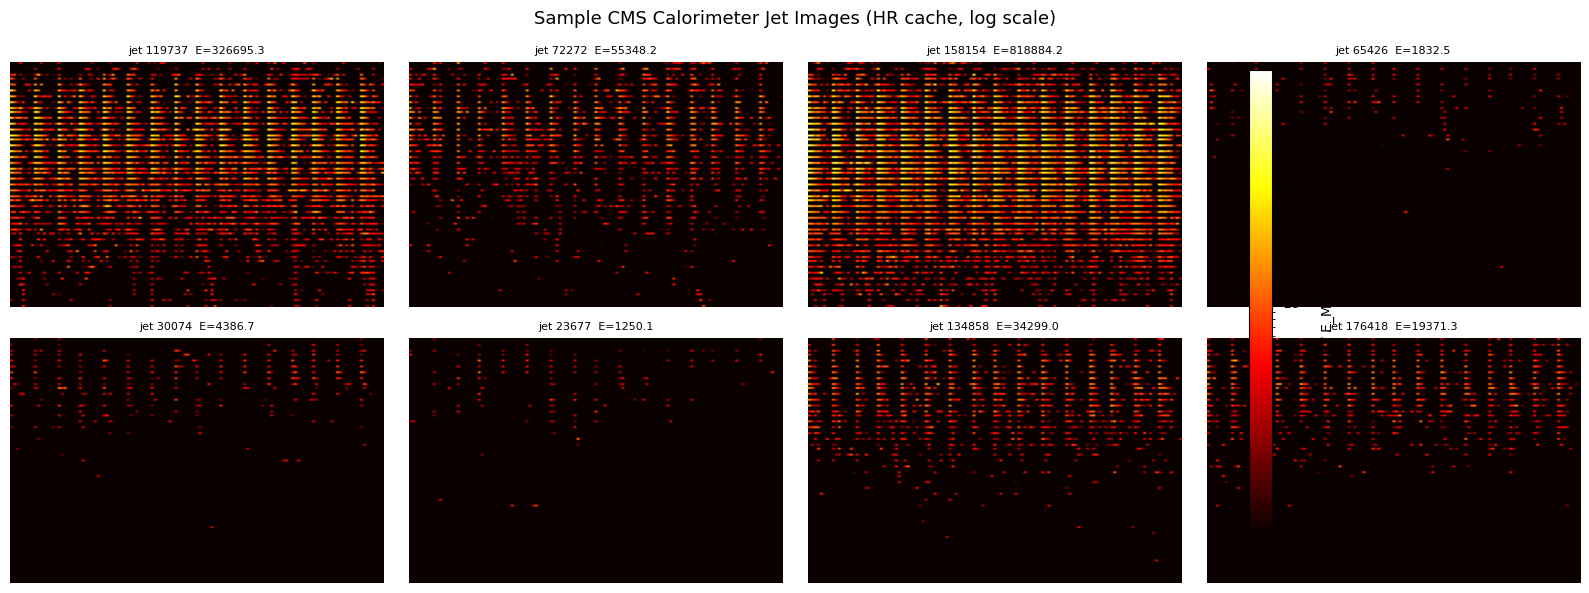

Saved: /kaggle/working/figures/2026-06-21/energy_distributions.png


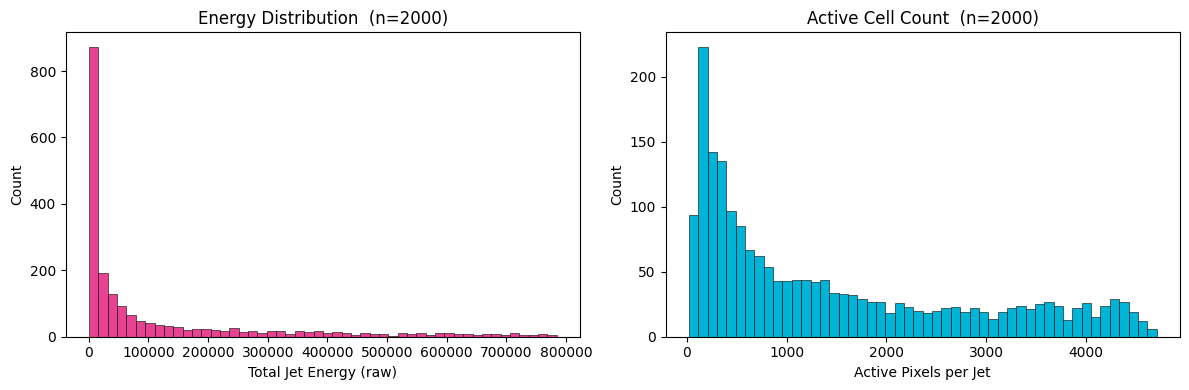

energies_raw  shape=(200000,)  min=1000.5470  max=999929.1250
hr_mm         shape=(200000, 1, 125, 125)
lr_mm         shape=(200000, 1, 64, 64)


In [10]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL: Visualisation  –  Sample Jets + Energy Distributions
# ═══════════════════════════════════════════════════════════════════════════════
from matplotlib.colors import LogNorm

hr_mm = np.load(cache_meta['hr_path'], mmap_mode='r')
lr_mm = np.load(cache_meta['lr_path'], mmap_mode='r')

# energies_raw is (N,) — flatten defensively in case an older cache wrote (N,1)
energies_raw = energies_raw.reshape(-1)

# ── Sample jet images ─────────────────────────────────────────────────────────
N_SHOW = 8
sel    = np.random.choice(N, N_SHOW, replace=False)

fig, axes = plt.subplots(2, N_SHOW // 2, figsize=(16, 6))
fig.suptitle('Sample CMS Calorimeter Jet Images (HR cache, log scale)', fontsize=13)

for i, ax in enumerate(axes.flat):
    img = np.clip(hr_mm[sel[i], 0], 1e-6, None)
    im  = ax.imshow(img, cmap='hot', norm=LogNorm(vmin=1e-4, vmax=1.0), aspect='auto')
    ax.set_title(f'jet {sel[i]}  E={energies_raw[sel[i]]:.1f}', fontsize=8)  # ← (N,) not (N,1)
    ax.axis('off')

fig.colorbar(im, ax=axes, label='E / E_MAX (log)')
plt.tight_layout()
savefig(fig, 'sample_jets')
plt.show()

# ── Energy + occupancy distributions (memmapped subset, no full load) ─────────
stat_n = min(2000, N)
ss     = np.sort(np.random.choice(N, stat_n, replace=False))
hr_sub = np.asarray(hr_mm[ss])   # (stat_n, C, H, W) — only this slice in RAM

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(
    (hr_sub * E_MAX).sum(axis=(1, 2, 3)),
    bins=50, color='#e84393', edgecolor='k', linewidth=0.4,
)
ax1.set_xlabel('Total Jet Energy (raw)')
ax1.set_ylabel('Count')
ax1.set_title(f'Energy Distribution  (n={stat_n})')

ax2.hist(
    (hr_sub > 0).sum(axis=(1, 2, 3)),
    bins=50, color='#00b4d8', edgecolor='k', linewidth=0.4,
)
ax2.set_xlabel('Active Pixels per Jet')
ax2.set_ylabel('Count')
ax2.set_title(f'Active Cell Count  (n={stat_n})')

plt.tight_layout()
savefig(fig, 'energy_distributions')
plt.show()

print(f'energies_raw  shape={energies_raw.shape}  '
      f'min={energies_raw.min():.4f}  max={energies_raw.max():.4f}')
print(f'hr_mm         shape={hr_mm.shape}')
print(f'lr_mm         shape={lr_mm.shape}')

Resolution Ladder:
  HR (256x256)  E=4.5489  sparsity=98.52%
  MR (125x125)  E=4.3986  sparsity=97.67%
  LR (64x64)  E=4.3986  sparsity=95.39%
Saved: /kaggle/working/figures/2026-06-21/resolution_ladder.png


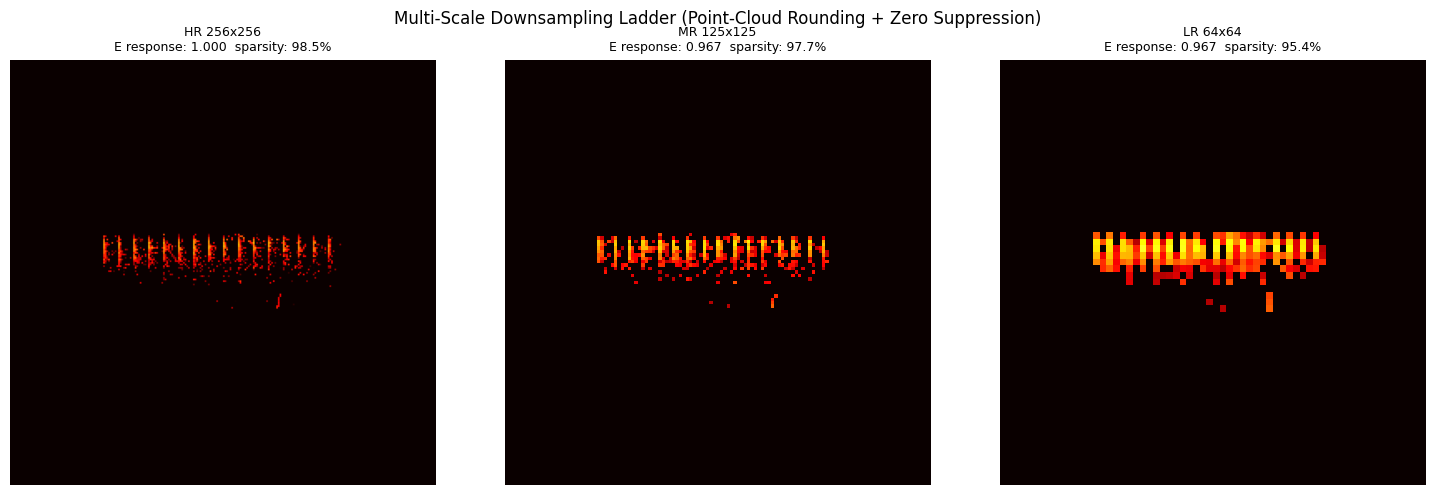

Saved: /kaggle/working/figures/2026-06-21/energy_vs_resolution.png


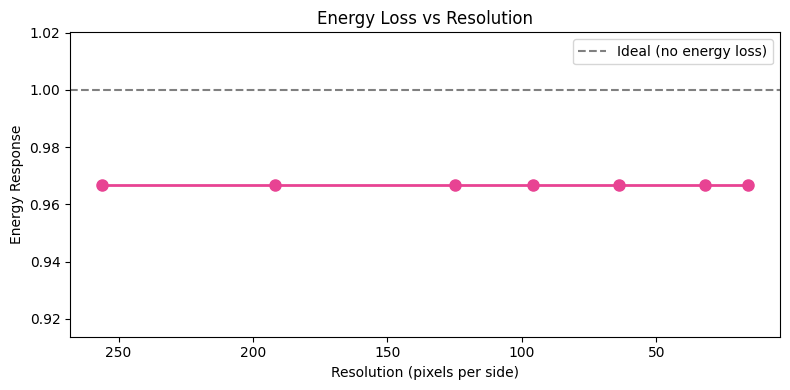

In [11]:
# Sample one raw shower for the ladder demo.
_demo, _ = sample_raw_images(hdf5_index, E_MAX, 1, cell_shape=CELL_SHAPE,
                              showers_key=SHOWERS_KEY, seed=7)
sample_raw = _demo[0]   # (C, 45, 144)

HR_H, HR_W = RESOLUTION_LADDER['HR']
sample_hr   = pad_to_resolution(sample_raw, HR_H, HR_W, zero_thresh=0.0)
sample_mr   = downsample_via_pointcloud(sample_hr, *RESOLUTION_LADDER['MR'],
                                        zero_thresh=ZERO_SUPPRESSION_THRESHOLD)
sample_lr   = downsample_via_pointcloud(sample_hr, *RESOLUTION_LADDER['LR'],
                                        zero_thresh=ZERO_SUPPRESSION_THRESHOLD)

print('Resolution Ladder:')
for name, arr in [('HR (256x256)', sample_hr), ('MR (125x125)', sample_mr),
                  ('LR (64x64)',   sample_lr)]:
    sparsity = (arr == 0).mean()
    print(f'  {name}  E={arr.sum():.4f}  sparsity={sparsity:.2%}')

scales = {'HR 256x256': sample_hr, 'MR 125x125': sample_mr, 'LR 64x64': sample_lr}
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Multi-Scale Downsampling Ladder (Point-Cloud Rounding + Zero Suppression)',
             fontsize=12)
for ax, (title, arr) in zip(axes, scales.items()):
    display = np.clip(arr[0], 1e-6, None)
    ax.imshow(display, cmap='hot', norm=LogNorm(vmin=1e-4, vmax=1.0), aspect='equal')
    e_resp = arr.sum() / (sample_hr.sum() + 1e-8)
    ax.set_title(f'{title}\nE response: {e_resp:.3f}  sparsity: {(arr==0).mean():.1%}',
                 fontsize=9)
    ax.axis('off')
plt.tight_layout()
savefig(fig, 'resolution_ladder')
plt.show()

# Energy response vs resolution.
resolutions = [256, 192, 125, 96, 64, 32, 16]
e_responses = []
for r in resolutions:
    ds = downsample_via_pointcloud(sample_hr, r, r,
                                   zero_thresh=ZERO_SUPPRESSION_THRESHOLD)
    e_responses.append(ds.sum() / (sample_hr.sum() + 1e-8))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(resolutions, e_responses, 'o-', color='#e84393', lw=2, ms=8)
ax.axhline(1.0, color='gray', ls='--', label='Ideal (no energy loss)')
ax.set_xlabel('Resolution (pixels per side)'); ax.set_ylabel('Energy Response')
ax.set_title('Energy Loss vs Resolution'); ax.legend(); ax.invert_xaxis()
plt.tight_layout()
savefig(fig, 'energy_vs_resolution')
plt.show()


Saved: /kaggle/working/figures/2026-06-21/pointcloud_3d.png


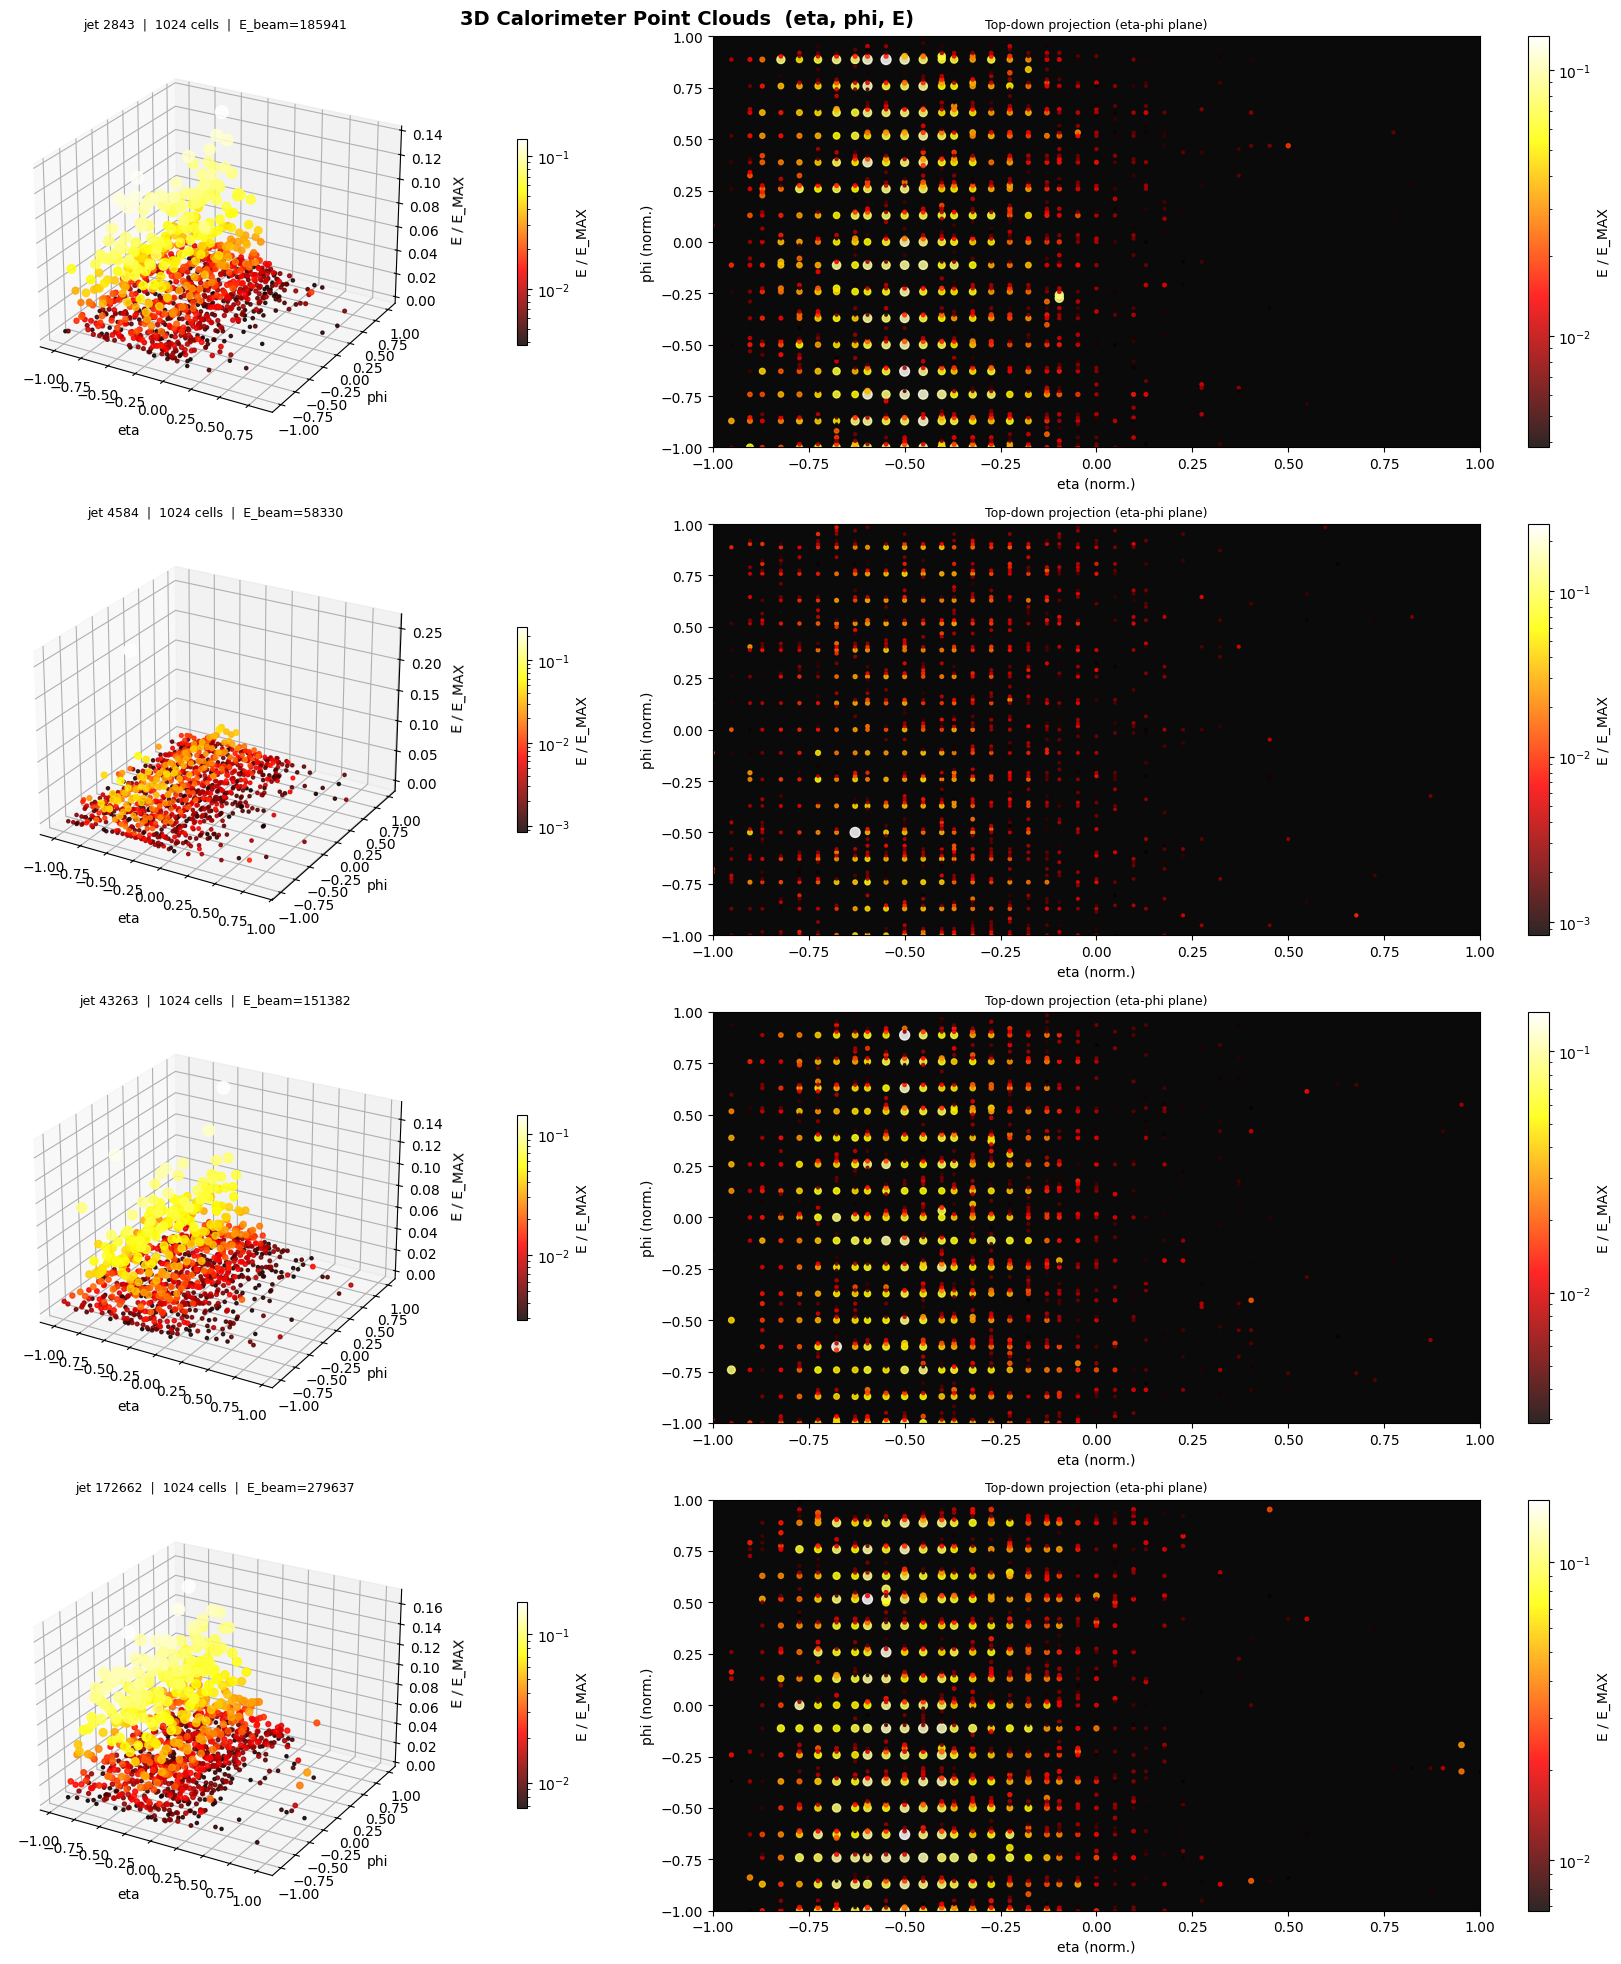

Saved: /kaggle/working/figures/2026-06-21/grid_vs_pointcloud.png


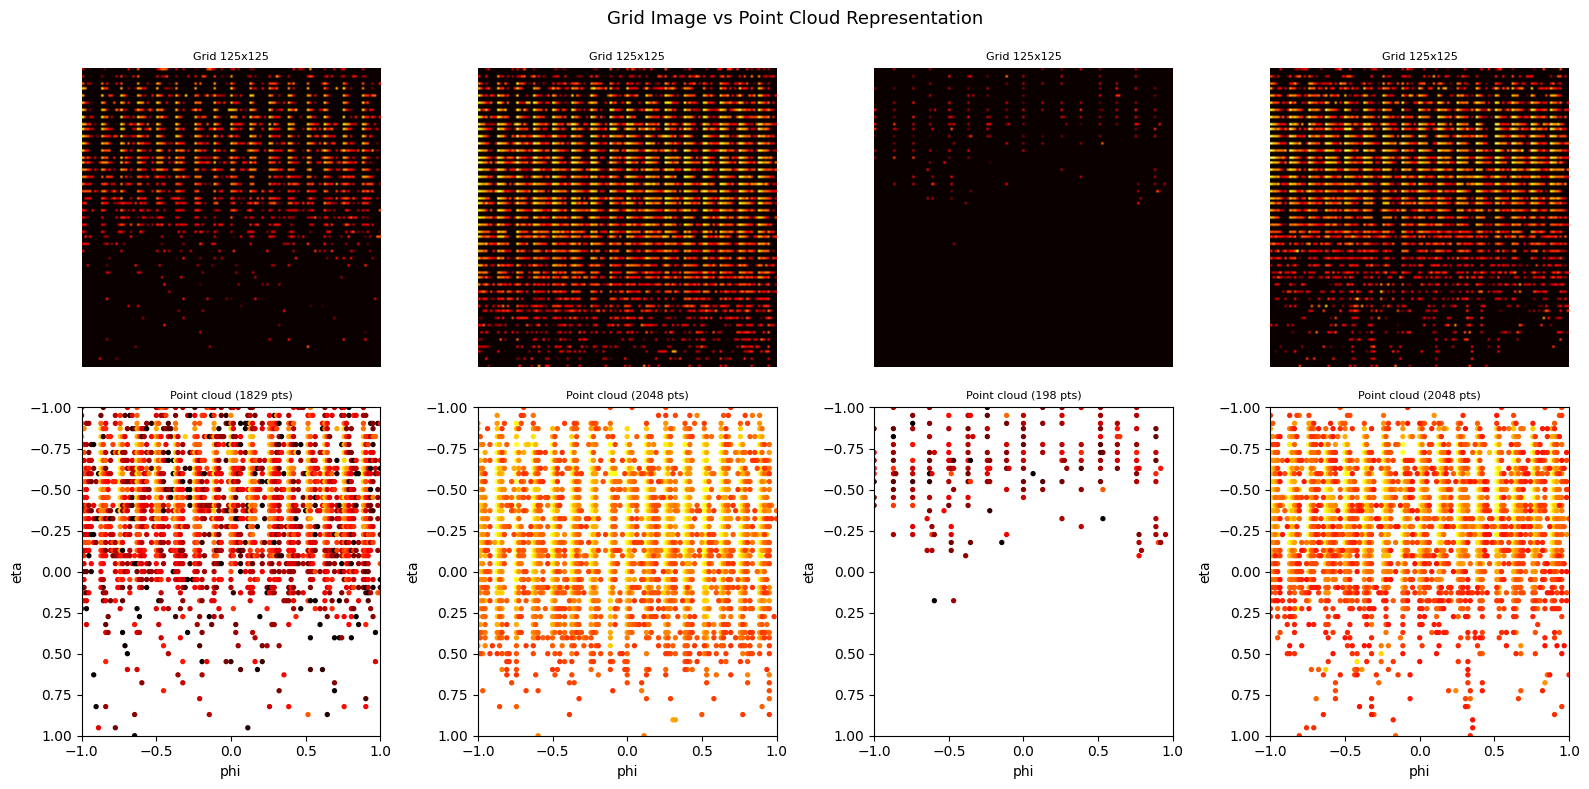

In [12]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL: 3D Point Cloud Visualisation  –  GatedINR CaloSR
# ═══════════════════════════════════════════════════════════════════════════════
from matplotlib.colors import LogNorm
from mpl_toolkits.mplot3d import Axes3D   # noqa: F401
import matplotlib.cm as cm

hr_mm    = np.load(cache_meta['hr_path'], mmap_mode='r')
energies_raw = energies_raw.reshape(-1)   # guard: (N,) either way

N_JETS   = 4
jet_idxs = np.random.choice(N, N_JETS, replace=False)

# ── 3D scatter + top-down projection ─────────────────────────────────────────
fig = plt.figure(figsize=(20, 5 * N_JETS))
fig.suptitle('3D Calorimeter Point Clouds  (eta, phi, E)',
             fontsize=14, fontweight='bold')

for row, ji in enumerate(jet_idxs):
    pc     = image_to_pointcloud(np.asarray(hr_mm[ji]), max_points=1024)
    active = pc[pc[:, 2] > 0]
    eta, phi, E = active[:, 0], active[:, 1], active[:, 2]

    E_norm = (E - E.min()) / (E.max() - E.min() + 1e-9)
    sizes  = 5 + 80 * E_norm

    # 3D scatter
    ax3d = fig.add_subplot(N_JETS, 2, row * 2 + 1, projection='3d')
    sc   = ax3d.scatter(
        eta, phi, E,
        c=E, cmap='hot', s=sizes, alpha=0.85, depthshade=True,
        norm=LogNorm(vmin=E.min() + 1e-6, vmax=E.max()),
    )
    ax3d.set_xlabel('eta', labelpad=6)
    ax3d.set_ylabel('phi', labelpad=6)
    ax3d.set_zlabel('E / E_MAX', labelpad=6)
    ax3d.set_title(
        f'jet {ji}  |  {len(active)} cells  |  E_beam={energies_raw[ji]:.0f}',  # ← fixed
        fontsize=9,
    )
    ax3d.view_init(elev=25, azim=-60)
    fig.colorbar(sc, ax=ax3d, shrink=0.5, pad=0.1, label='E / E_MAX')

    # Top-down (eta-phi)
    ax2d = fig.add_subplot(N_JETS, 2, row * 2 + 2)
    sc2  = ax2d.scatter(
        eta, phi,
        c=E, cmap='hot', s=sizes * 0.6, alpha=0.85,
        norm=LogNorm(vmin=E.min() + 1e-6, vmax=E.max()),
    )
    ax2d.set_xlabel('eta (norm.)')
    ax2d.set_ylabel('phi (norm.)')
    ax2d.set_title('Top-down projection (eta-phi plane)', fontsize=9)
    ax2d.set_facecolor('#0a0a0a')
    ax2d.set_xlim(-1, 1)
    ax2d.set_ylim(-1, 1)
    fig.colorbar(sc2, ax=ax2d, label='E / E_MAX')

plt.tight_layout()
savefig(fig, 'pointcloud_3d')
plt.show()

# ── Grid vs point cloud side-by-side for 4 jets ───────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Grid Image vs Point Cloud Representation', fontsize=13)

for col in range(4):
    img_3d = np.asarray(hr_mm[col])
    img    = img_3d[0]
    pc     = image_to_pointcloud(img_3d, max_points=2048)
    active = pc[pc[:, 2] > 0]

    axes[0, col].imshow(
        np.clip(img, 1e-6, None), cmap='hot',
        norm=LogNorm(vmin=1e-4, vmax=1.0), aspect='equal',
    )
    axes[0, col].set_title(f'Grid {img.shape[0]}x{img.shape[1]}', fontsize=8)
    axes[0, col].axis('off')

    sc = axes[1, col].scatter(
        active[:, 1], active[:, 0], c=active[:, 2],
        cmap='hot', s=8, norm=LogNorm(vmin=1e-4, vmax=1.0),
    )
    axes[1, col].set_xlim(-1, 1)
    axes[1, col].set_ylim(-1, 1)
    axes[1, col].set_title(f'Point cloud ({len(active)} pts)', fontsize=8)
    axes[1, col].set_xlabel('phi')
    axes[1, col].set_ylabel('eta')
    axes[1, col].invert_yaxis()

plt.tight_layout()
savefig(fig, 'grid_vs_pointcloud')
plt.show()

In [13]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL: Dataset Split + DataLoaders  –  GatedINR CaloSR
# ═══════════════════════════════════════════════════════════════════════════════
import os, random
import numpy as np
import torch
from torch.utils.data import DataLoader

# ── FIX 6: Set num_workers to use all available vCPUs ────────────────────────
# Kaggle T4 notebooks have 4 vCPUs. min(2, ...) was starving the pipeline.
# 4 workers means 4 samples are being prepared while GPU runs the current batch.
_CPU_COUNT   = os.cpu_count() or 2
NUM_WORKERS  = min(4, _CPU_COUNT)    # 4 on Kaggle; safe ceiling elsewhere

# ── FIX 7: prefetch_factor 2, not 4 ─────────────────────────────────────────
# prefetch_factor=4 with memmap + numpy allocs causes excessive RSS growth and
# can trigger OOM-killed workers on T4 (16 GB shared with GPU). 2 is enough
# to hide the memmap page-fault latency while keeping peak worker RAM low.
_PREFETCH    = 2

PIN_MEMORY   = torch.cuda.is_available()

# ── Guard: flatten to (N,) in case older cache wrote (N,1) ──────────────────
energies_raw = energies_raw.reshape(-1)

# ── Worker seeding — reproducible per-worker RNG ─────────────────────────────
def _worker_init_fn(worker_id: int):
    seed = SEED + worker_id
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    # No HDF5 handle opened here — CalorimeterSRDataset._get_cache_mm()
    # opens memmaps lazily on first __getitem__ call in each worker.
    # This is correct: __getstate__ nulls out _hr_mm/_lr_mm before pickling,
    # so each forked worker gets a fresh handle automatically.

# ── Train / val split ────────────────────────────────────────────────────────
TRAIN_FRAC = 0.85
N_TRAIN    = int(N * TRAIN_FRAC)
perm       = np.random.permutation(N)
train_pos, val_pos = perm[:N_TRAIN], perm[N_TRAIN:]

common = dict(
    hr_res       = HR_RES,
    lr_res       = LR_RES,
    max_points   = 512,
    n_query      = 512,
    nonzero_frac = 0.3,
    zero_thresh  = ZERO_SUPPRESSION_THRESHOLD,
    cache        = cache_meta,
)

train_dataset = CalorimeterSRDataset(
    beam_energies = energies_raw[train_pos],
    cache_rows    = train_pos,
    augment       = True,
    **common,
)
val_dataset = CalorimeterSRDataset(
    beam_energies = energies_raw[val_pos],
    cache_rows    = val_pos,
    augment       = False,
    **common,
)

# ── FIX 8: BATCH_SIZE scaled for DataParallel ────────────────────────────────
# DataParallel splits each batch across N GPUs. With 2× T4:
#   BATCH_SIZE=64  → 32 samples/GPU  (minimum viable arithmetic intensity)
#   BATCH_SIZE=128 → 64 samples/GPU  (try this if VRAM allows)
# Your point clouds are (512, 2+C) float32 — small tensors, VRAM is not the
# bottleneck, so push batch size as high as possible before OOMing.
BATCH_SIZE = 128    # increase to 128 if no OOM after first epoch

# ── DataLoaders ──────────────────────────────────────────────────────────────
def _make_loader(dataset, shuffle: bool) -> DataLoader:
    kw = dict(
        batch_size     = BATCH_SIZE,
        num_workers    = NUM_WORKERS,
        pin_memory     = PIN_MEMORY,
        shuffle        = shuffle,
        worker_init_fn = _worker_init_fn,
        # FIX 9: drop_last=True — prevents uneven DataParallel scatter on the
        # last batch (e.g. 64 samples → GPU0 gets 33, GPU1 gets 31 → shape
        # mismatch in gather). Costs at most 1 batch per epoch, negligible.
        drop_last      = True,
    )
    if NUM_WORKERS > 0:
        kw.update(
            persistent_workers = True,
            prefetch_factor    = _PREFETCH,   # 2, not 4
        )
    return DataLoader(dataset, **kw)

train_loader = _make_loader(train_dataset, shuffle=True)
val_loader   = _make_loader(val_dataset,   shuffle=False)

print(f'Train : {len(train_dataset):,} samples  |  {len(train_loader)} batches')
print(f'Val   : {len(val_dataset):,} samples  |  {len(val_loader)} batches')
print(f'Batch={BATCH_SIZE}  workers={NUM_WORKERS}  '
      f'pin_memory={PIN_MEMORY}  persistent_workers={NUM_WORKERS > 0}  '
      f'prefetch_factor={_PREFETCH}  drop_last=True')

# ── Smoke-test one batch ──────────────────────────────────────────────────────
_batch = next(iter(train_loader))
print('\nBatch shapes:')
for k, v in _batch.items():
    print(f'  {k:12s}  {str(tuple(v.shape)):30s}  dtype={v.dtype}')
del _batch

Train : 170,000 samples  |  1328 batches
Val   : 30,000 samples  |  234 batches
Batch=128  workers=4  pin_memory=True  persistent_workers=True  prefetch_factor=2  drop_last=True

Batch shapes:
  lr_pc         (128, 512, 3)                   dtype=torch.float32
  hr_img        (128, 1, 125, 125)              dtype=torch.float32
  lr_img        (128, 1, 64, 64)                dtype=torch.float32
  query_pts     (128, 512, 2)                   dtype=torch.float32
  query_e       (128, 512, 1)                   dtype=torch.float32
  beam_e        (128,)                          dtype=torch.float32


In [14]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL: Model Architecture  –  PointNet Encoder + Gated SIREN-INR Decoder
#       GatedINR CaloSR  |  v2 — destriping + precision-focused parameter changes
#
#  KEY CHANGES vs v1 (all target the occupancy over-prediction / stripe problem):
#    1. Separate Fourier embeddings:  occ = LOW freq (smooth),  mag = HIGH freq (sharp)
#    2. Occupancy init bias  -3.0 -> -4.0   (stronger sparse prior)
#    3. Occupancy depth  2 -> 3 hidden layers  + dropout 0.10
#    4. omega_0  30 -> 25  (smoother magnitude field, stabler energy response)
#    5. OCC_THRESHOLD  0.65 -> 0.80  (inference gate cuts active rate / raises precision)
# ═══════════════════════════════════════════════════════════════════════════════
import math
import torch
import torch.nn as nn
import torch.nn.functional as F


# ───────────────────────────────────────────────────────────────────────────────
# 1.  PointNet Encoder   (unchanged)
#     (B, N, 2+C)  →  (B, latent_dim)
# ───────────────────────────────────────────────────────────────────────────────
class PointNetEncoder(nn.Module):
    """Lightweight PointNet encoder. (B,N,2+C) -> (B,latent_dim) global latent z."""
    def __init__(self, in_features: int, latent_dim: int = 256):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Conv1d(in_features, 64,  1), nn.BatchNorm1d(64),  nn.ReLU(),
            nn.Conv1d(64,  128, 1),          nn.BatchNorm1d(128), nn.ReLU(),
            nn.Conv1d(128, 256, 1),          nn.BatchNorm1d(256), nn.ReLU(),
        )
        self.head = nn.Sequential(
            nn.Linear(256, 256), nn.LayerNorm(256), nn.GELU(),
            nn.Linear(256, latent_dim),
        )

    def forward(self, pc: torch.Tensor) -> torch.Tensor:
        x = pc.transpose(1, 2)         # (B, 2+C, N)
        x = self.mlp(x)                # (B, 256,  N)
        x = x.max(dim=-1).values       # global max-pool → (B, 256)
        return self.head(x)            # (B, latent_dim)


# ───────────────────────────────────────────────────────────────────────────────
# 2.  Coordinate Embedding  (Fourier Features)   (unchanged)
#     Now instantiated TWICE with different n_freqs (see decoder).
# ───────────────────────────────────────────────────────────────────────────────
class FourierEmbedding(nn.Module):
    """Deterministic log-spaced Fourier features. out_dim = 2 * n_freqs * coord_dim."""
    def __init__(self, coord_dim: int = 2, n_freqs: int = 8):
        super().__init__()
        freqs = 2.0 ** torch.arange(n_freqs).float() * math.pi   # π, 2π, ..., 2^(n-1)·π
        self.register_buffer('freqs', freqs)
        self.coord_dim = coord_dim
        self.n_freqs   = n_freqs
        self.out_dim   = 2 * n_freqs * coord_dim

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        proj = x.unsqueeze(-1) * self.freqs         # (..., coord_dim, n_freqs)
        proj = proj.flatten(-2)                     # (..., coord_dim * n_freqs)
        return torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)


# ───────────────────────────────────────────────────────────────────────────────
# 3a. SIREN Layer   (unchanged)
# ───────────────────────────────────────────────────────────────────────────────
class SineLayer(nn.Module):
    def __init__(self, in_f: int, out_f: int,
                 omega_0: float = 25.0, is_first: bool = False):
        super().__init__()
        self.omega_0 = omega_0
        self.linear  = nn.Linear(in_f, out_f)
        with torch.no_grad():
            if is_first:
                self.linear.weight.uniform_(-1 / in_f, 1 / in_f)
            else:
                b = math.sqrt(6 / in_f) / omega_0
                self.linear.weight.uniform_(-b, b)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return torch.sin(self.omega_0 * self.linear(x))


# ───────────────────────────────────────────────────────────────────────────────
# 3b. Magnitude Head  (SIREN trunk → softplus)   (unchanged structure)
#     Keeps HIGH-freq Fourier input — energy peaks must stay sharp.
# ───────────────────────────────────────────────────────────────────────────────
class MagnitudeHead(nn.Module):
    """Input [Fourier_HI(query), z] -> non-negative magnitude (B,N_q,out_C)."""
    def __init__(self, in_dim: int, hidden_dim: int,
                 n_layers: int, out_C: int, omega_0: float = 25.0):
        super().__init__()
        self.first  = SineLayer(in_dim, hidden_dim, omega_0, is_first=True)
        self.hidden = nn.ModuleList([
            SineLayer(hidden_dim, hidden_dim, omega_0)
            for _ in range(max(0, n_layers - 2))
        ])
        self.out = nn.Linear(hidden_dim, out_C)
        nn.init.constant_(self.out.bias, 0.0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.first(x)
        for layer in self.hidden:
            x = layer(x)
        return F.softplus(self.out(x))


# ───────────────────────────────────────────────────────────────────────────────
# 3c. Occupancy Head  (Fourier_LO + deeper ReLU-MLP + dropout → logit)
#     CHANGED:
#       • 3 hidden layers (was 2)  — capacity to localize instead of striping
#       • dropout (default 0.10)   — regularize away from row-periodic memorization
#       • bias_init default -4.0   — stronger sparse prior, sigmoid(-4)=0.018
#     Fed LOW-freq Fourier only (set in decoder) so it physically *cannot*
#     paint sub-16px horizontal stripes.
# ───────────────────────────────────────────────────────────────────────────────
class OccupancyHead(nn.Module):
    """Input [raw_query(2), Fourier_LO(query), z] -> raw logits (B,N_q,out_C)."""
    def __init__(self, in_dim: int, hidden_dim: int, out_C: int,
                 dropout: float = 0.10, bias_init: float = -4.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),     nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, out_C),
        )
        # Bias toward 'empty' — calorimeter data is ~95% zero. -4.0 => 1.8% prior.
        nn.init.constant_(self.net[-1].bias, bias_init)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


# ───────────────────────────────────────────────────────────────────────────────
# 4.  Gated INR Decoder
#     CHANGED: two separate Fourier embeddings.
#       fourier_mag : HIGH freq (n=8)  → sharp magnitude peaks
#       fourier_occ : LOW  freq (n=4)  → smooth occupancy, no stripes
# ───────────────────────────────────────────────────────────────────────────────
class GatedINRDecoder(nn.Module):
    """z (B,latent), query (B,N_q,2) -> energy [+occ_logit, magnitude]."""
    def __init__(self, latent_dim: int = 256, hidden_dim: int = 256,
                 n_layers: int = 5, out_C: int = 1, omega_0: float = 25.0,
                 n_fourier_mag: int = 8, n_fourier_occ: int = 4,
                 occ_dropout: float = 0.10, occ_bias_init: float = -4.0):
        super().__init__()
        # HIGH-freq for magnitude (sharp peaks), LOW-freq for occupancy (smooth)
        self.fourier_mag = FourierEmbedding(coord_dim=2, n_freqs=n_fourier_mag)
        self.fourier_occ = FourierEmbedding(coord_dim=2, n_freqs=n_fourier_occ)

        mag_in        = self.fourier_mag.out_dim + latent_dim
        self.mag_head = MagnitudeHead(mag_in, hidden_dim, n_layers, out_C, omega_0)

        occ_in        = 2 + self.fourier_occ.out_dim + latent_dim
        self.occ_head = OccupancyHead(occ_in, hidden_dim, out_C,
                                      dropout=occ_dropout, bias_init=occ_bias_init)

    def forward(self, z: torch.Tensor, query: torch.Tensor,
                return_parts: bool = False):
        B, N_q, _ = query.shape
        z_exp     = z.unsqueeze(1).expand(-1, N_q, -1)        # (B, N_q, latent)

        ff_mag    = self.fourier_mag(query)                   # HIGH freq
        ff_occ    = self.fourier_occ(query)                   # LOW freq

        # Magnitude pathway: HIGH-freq Fourier + z → SIREN → softplus
        magnitude = self.mag_head(torch.cat([ff_mag, z_exp], dim=-1))

        # Occupancy pathway: raw coords + LOW-freq Fourier + z → ReLU-MLP → logit
        occ_logit = self.occ_head(torch.cat([query, ff_occ, z_exp], dim=-1))

        # Gating: E(η,φ) = sigmoid(o) × m
        energy    = torch.sigmoid(occ_logit) * magnitude

        if return_parts:
            return energy, occ_logit, magnitude
        return energy


# ───────────────────────────────────────────────────────────────────────────────
# 5.  Full Pipeline  –  GatedINR  (== ResolutionInvariantSR)
# ───────────────────────────────────────────────────────────────────────────────

# Hard occupancy threshold at inference. RAISED 0.65 -> 0.80.
# This is the most direct lever on the active-rate / precision tradeoff.
# Sweep it on the validation set (see note below the model) to pick the
# precision/recall balance you want — higher = sparser + higher precision.
OCC_THRESHOLD = 0.80


class GatedINR(nn.Module):
    """
    Full PointNet + Gated SIREN-INR super-resolution pipeline (v2).

    Args:
        C             : energy channels (1 for CMS calorimeter)
        latent_dim    : encoder output / decoder conditioning dim
        hidden_dim    : width of SIREN and occupancy MLP
        n_layers      : depth of SIREN magnitude trunk (≥ 2)
        omega_0       : SIREN frequency multiplier (25.0 → smoother field)
        n_fourier_mag : Fourier freqs for MAGNITUDE  (high, keeps peaks sharp)
        n_fourier_occ : Fourier freqs for OCCUPANCY  (low, prevents stripes)
        occ_dropout   : dropout in occupancy MLP (regularization)
        occ_bias_init : occupancy output bias init (sparse prior; -4.0 = 1.8%)
    """
    def __init__(self, C: int = 1, latent_dim: int = 256,
                 hidden_dim: int = 256, n_layers: int = 5,
                 omega_0: float = 25.0,
                 n_fourier_mag: int = 8, n_fourier_occ: int = 4,
                 occ_dropout: float = 0.10, occ_bias_init: float = -4.0):
        super().__init__()
        self.C       = C
        self.encoder = PointNetEncoder(in_features=2 + C, latent_dim=latent_dim)
        self.decoder = GatedINRDecoder(
            latent_dim    = latent_dim,
            hidden_dim    = hidden_dim,
            n_layers      = n_layers,
            out_C         = C,
            omega_0       = omega_0,
            n_fourier_mag = n_fourier_mag,
            n_fourier_occ = n_fourier_occ,
            occ_dropout   = occ_dropout,
            occ_bias_init = occ_bias_init,
        )

    def forward(self, lr_pc: torch.Tensor, query_pts: torch.Tensor,
                return_parts: bool = False):
        z = self.encoder(lr_pc)
        return self.decoder(z, query_pts, return_parts=return_parts)

    @torch.no_grad()
    def rasterise(self, lr_pc: torch.Tensor,
                  target_H: int, target_W: int,
                  occ_threshold: float = OCC_THRESHOLD) -> torch.Tensor:
        """Dense image at ANY (target_H, target_W). eval() disables dropout."""
        self.eval()   # IMPORTANT: turns off the new occupancy dropout at inference
        B, dev = lr_pc.shape[0], lr_pc.device
        eta  = torch.linspace(-1, 1, target_H, device=dev)
        phi  = torch.linspace(-1, 1, target_W, device=dev)
        ETA, PHI = torch.meshgrid(eta, phi, indexing='ij')
        grid = (torch.stack([ETA.flatten(), PHI.flatten()], dim=-1)
                .unsqueeze(0).expand(B, -1, -1))

        energy, occ_logit, _ = self.forward(lr_pc, grid, return_parts=True)

        energy = torch.where(
            torch.sigmoid(occ_logit) > occ_threshold,
            energy, torch.zeros_like(energy),
        )
        return energy.transpose(1, 2).reshape(B, self.C, target_H, target_W)


ResolutionInvariantSR = GatedINR   # backwards-compat alias


# ═══════════════════════════════════════════════════════════════════════════════
# Instantiate + sanity-check
# ═══════════════════════════════════════════════════════════════════════════════
model = GatedINR(
    C             = C,
    latent_dim    = 256,
    hidden_dim    = 256,
    n_layers      = 5,
    omega_0       = 25.0,    # was 30.0
    n_fourier_mag = 8,       # magnitude keeps high freq
    n_fourier_occ = 4,       # occupancy capped low → no stripes
    occ_dropout   = 0.10,    # new
    occ_bias_init = -4.0,    # was -3.0
).to(DEVICE)

if DEVICE == 'cuda' and tuple(int(x) for x in torch.__version__.split('.')[:2]) >= (2, 0):
    try:
        model = torch.compile(model)
        print('torch.compile() applied.')
    except Exception as e:
        print(f'torch.compile() skipped: {e}')

n_params = sum(p.numel() for p in model.parameters())
print(f'Model         : GatedINR v2 (PointNet + Gated SIREN-INR)')
print(f'Parameters    : {n_params:,}')

# Forward smoke-test
dummy_pc    = torch.zeros(4, 512, 2 + C, device=DEVICE)
dummy_query = torch.rand(4, 256, 2,      device=DEVICE) * 2 - 1

out         = model(dummy_pc, dummy_query)
e, occ, mag = model(dummy_pc, dummy_query, return_parts=True)
print(f'Forward OK    : energy={tuple(e.shape)}  occ={tuple(occ.shape)}  mag={tuple(mag.shape)}')

for res in [64, 125, 256]:
    shape = tuple(model.rasterise(dummy_pc, res, res).shape)
    print(f'Rasterise {res:3d}x{res:<3d}: {shape}')

torch.compile() applied.
Model         : GatedINR v2 (PointNet + Gated SIREN-INR)
Parameters    : 648,450


W0621 07:21:34.902000 58 torch/_inductor/utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode


Forward OK    : energy=(4, 256, 1)  occ=(4, 256, 1)  mag=(4, 256, 1)
Rasterise  64x64 : (4, 1, 64, 64)
Rasterise 125x125: (4, 1, 125, 125)
Rasterise 256x256: (4, 1, 256, 256)


In [15]:
# ── Cell 14 (CELL 24): Physics-aware loss — updated ──────────────────────────
#
# NEW vs old:
#   l_energy  : was  |sum_pred - sum_gt|  (MAE — treats over/under equally)
#               now  (sum_pred/sum_gt - 1)^2  (ratio loss — dimensionless,
#                     squaring punishes energy hallucination harder)
#   l_overflow: NEW — mean(relu(E_pred - E_gt)) — penalises any query point
#               where the model predicts MORE energy than the HR ground truth.
#               This is what kills the "predicts too much energy" symptom:
#               softplus magnitude + soft gate can freely hallucinate above GT;
#               l_overflow gives a direct gradient to pull it back down.
#   lambda_energy: bumped 0.2 -> 0.5  (stronger conservation signal)
#   lambda_overflow: 0.5 default — tune up if response still >1.05

class PhysicsAwareLoss(nn.Module):
    """
    Loss for the gated INR decoder. Five components:

      1. l_occ      — occupancy BCE: sigmoid(occ_logit) vs (E_gt > thresh)
                       learns WHERE energy is; drives hard zeros at empty pixels
      2. l_rec      — weighted L1: active pixels upweighted 10x over background
      3. l_energy   — energy ratio: (sum_pred / sum_gt - 1)^2 per jet, averaged
                       dimensionless; penalises over-prediction harder than MAE did
      4. l_overflow — per-query overflow: mean(relu(E_pred - E_gt))
                       directly penalises any pixel where model exceeds GT energy
                       THIS is the main fix for "predicts too much energy"
      5. l_interp   — interpolation smoothness: mean(|grad_pred|) encouraging
                       the INR to not hallucinate spiky deposits between real ones
                       (the HR upsampling artifact you described)

    Recommended starting lambdas:
      lambda_rec=1.0, lambda_energy=0.5, lambda_occ=3.0,
      lambda_overflow=0.5, lambda_interp=0.1
    Increase lambda_overflow to 1.0-2.0 if energy response still > 1.05 after
    a few epochs.
    """

    def __init__(self,
                 lambda_rec:      float = 1.0,
                 lambda_energy:   float = 0.5,   # bumped from 0.2
                 lambda_occ:      float = 3.0,
                 lambda_overflow: float = 0.5,   # NEW
                 lambda_interp:   float = 0.1,   # NEW
                 nonzero_weight:  float = 10.0,
                 occ_pos_weight:  float = 2.0,
                 zero_thresh:     float = ZERO_SUPPRESSION_THRESHOLD):
        super().__init__()
        self.lam_rec      = lambda_rec
        self.lam_energy   = lambda_energy
        self.lam_occ      = lambda_occ
        self.lam_overflow = lambda_overflow
        self.lam_interp   = lambda_interp
        self.alpha        = nonzero_weight
        self.occ_pos_w    = occ_pos_weight
        self.thresh       = zero_thresh

    def forward(self, E_pred, E_gt, occ_logit=None, query_pts=None):
        """
        E_pred     : (B, N_q, C)  predicted energy at query points
        E_gt       : (B, N_q, C)  HR ground-truth energy at those points
        occ_logit  : (B, N_q, C)  raw logits from occupancy head
        query_pts  : (B, N_q, 2)  (eta, phi) coords — needed for l_interp only;
                                   pass None to skip interpolation smoothness loss
        """
        target_occ = (E_gt > self.thresh).float()   # (B, N_q, C)

        # ── 1. Occupancy BCE ─────────────────────────────────────────────────
        if occ_logit is not None:
            pw    = torch.tensor(self.occ_pos_w, device=occ_logit.device)
            l_occ = F.binary_cross_entropy_with_logits(occ_logit, target_occ, pos_weight=pw)
        else:
            l_occ = E_pred.new_zeros(())

        # ── 2. Weighted L1 reconstruction ────────────────────────────────────
        active   = target_occ
        n_act    = active.sum().clamp(min=1)
        l_rec_active = ((E_pred - E_gt).abs() * active).sum() / n_act
        l_rec_all    = (E_pred - E_gt).abs().mean()
        l_rec        = l_rec_active + 0.1 * l_rec_all

        # ── 3. Energy ratio conservation (NEW formula) ───────────────────────
        # ratio per jet: (sum_pred / sum_gt - 1)^2
        # Summing over query points (N_q, C) gives a proportional estimate of
        # total jet energy from the sampled queries — unbiased under uniform sampling.
        E_sum_pred = E_pred.sum(dim=(1, 2))                          # (B,)
        E_sum_gt   = E_gt.sum(dim=(1, 2)).clamp(min=1e-6)           # (B,)
        ratio      = E_sum_pred / E_sum_gt                           # (B,)
        l_energy   = ((ratio - 1.0) ** 2).mean()                    # dimensionless

        # ── 4. Per-pixel overflow penalty (NEW) ──────────────────────────────
        # relu(E_pred - E_gt): zero where model is below GT, positive where it
        # overshoots. Gives a direct gradient to suppress energy hallucination.
        l_overflow = F.relu(E_pred - E_gt).mean()

        # ── 5. Interpolation smoothness (NEW) ────────────────────────────────
        # Penalises spiky high-energy predictions between real deposits.
        # Implemented as the mean absolute difference between neighbouring query
        # points sorted by eta coordinate — a cheap 1-D finite-difference proxy.
        # Only computed when query_pts is provided (skip during val if slow).
        if query_pts is not None and self.lam_interp > 0:
            # Sort queries by eta within each batch element
            sort_idx  = query_pts[..., 0].argsort(dim=1)             # (B, N_q)
            E_sorted  = E_pred.gather(
                1, sort_idx.unsqueeze(-1).expand_as(E_pred))         # (B, N_q, C)
            l_interp  = (E_sorted[:, 1:] - E_sorted[:, :-1]).abs().mean()
        else:
            l_interp  = E_pred.new_zeros(())

        # ── Total ─────────────────────────────────────────────────────────────
        total = (self.lam_rec      * l_rec     +
                 self.lam_energy   * l_energy  +
                 self.lam_occ      * l_occ     +
                 self.lam_overflow * l_overflow +
                 self.lam_interp   * l_interp)

        # ── Diagnostics (no_grad) ─────────────────────────────────────────────
        with torch.no_grad():
            response  = ratio.clamp(0, 10).mean()
            if occ_logit is not None:
                pred_hit  = (torch.sigmoid(occ_logit) > 0.5).float()
                tp        = (pred_hit * target_occ).sum()
                recall    = tp / target_occ.sum().clamp(min=1)
                precision = tp / pred_hit.sum().clamp(min=1)
            else:
                recall = precision = E_pred.new_zeros(())

        return {
            'loss':       total,
            'l_rec':      l_rec.item(),
            'l_energy':   l_energy.item(),
            'l_occ':      l_occ.item(),
            'l_overflow': l_overflow.item(),   # watch this: should trend toward 0
            'l_interp':   l_interp.item() if isinstance(l_interp, torch.Tensor) else 0.0,
            'response':   response.item(),
            'recall':     float(recall),
            'precision':  float(precision),
        }


criterion = PhysicsAwareLoss(
    lambda_rec=1.0,
    lambda_energy=0.5,
    lambda_occ=3.0,
    lambda_overflow=0.5,
    lambda_interp=0.1,
    occ_pos_weight=3.0,   # bump from 2.0 — v2 sparse prior is stronger
)

In [16]:
# ═══════════════════════════════════════════════════════════════════════════════
# CELL: Training Loop  –  GatedINR CaloSR
#       HPO disabled — using pre-tuned best params from Optuna trial #4
# ═══════════════════════════════════════════════════════════════════════════════

torch.backends.cudnn.benchmark = True

import contextlib, gc, math, os, time
import torch
import torch.nn as nn
from tqdm.std import tqdm
from torch.utils.data import DataLoader

# ── Fixed globals ─────────────────────────────────────────────────────────────
EPOCHS    = 30
LOG_EVERY = 1
CKPT_PATH = os.path.join(CKPT_DIR, 'best_sr_model.pt')


# ═══════════════════════════════════════════════════════════════════════════════
# Pre-tuned hyperparameters  (Optuna trial #4, val_loss=1.03792)
# ═══════════════════════════════════════════════════════════════════════════════
BEST_PARAMS = {
    'lr_base'      : 3.001230180898045e-05,
    'lr_occ'       : 0.0017444803725696117,
    'weight_decay' : 1.913588048769229e-05,
    'clip_grad'    : 1.7032954711310595,
    'warmup'       : 2,
    'latent_dim'   : 128,
    'hidden_dim'   : 256,
    'n_layers'     : 5,
    'omega_0'      : 35.42540693371892,
    'n_fourier'    : 8,
}


# ── Helper: safely extract a scalar from tensor OR plain float ────────────────
def _scalar(v) -> float:
    if isinstance(v, torch.Tensor):
        return v.item()
    return float(v)


# ═══════════════════════════════════════════════════════════════════════════════
# run_epoch
# ═══════════════════════════════════════════════════════════════════════════════
def run_epoch(loader, model, criterion, optimizer, scaler,
              clip_grad: float, train: bool, use_amp: bool,
              trial=None, epoch_idx: int = 0, desc: str = '') -> dict:

    model.train(train)

    totals = {k: 0.0 for k in [
        'loss', 'l_rec', 'l_energy', 'l_occ',
        'l_overflow', 'l_interp', 'response', 'recall', 'precision',
    ]}

    n    = len(loader)
    pbar = tqdm(loader, desc=desc, leave=False, total=n,
                dynamic_ncols=True, mininterval=2.0)

    train_ctx = torch.enable_grad() if train else torch.no_grad()

    # ── FIX: construct context managers upfront; enter with `with amp_ctx`  ──
    # Old code used a lambda which silently ran everything in float32 because
    # the lambda was never actually entered as a context manager.
    amp_ctx = (torch.autocast(device_type='cuda', dtype=torch.float16)
               if use_amp else contextlib.nullcontext())

    try:
        with train_ctx:
            for batch in pbar:
                lr_pc     = batch['lr_pc'].to(DEVICE,    non_blocking=True)
                query_pts = batch['query_pts'].to(DEVICE, non_blocking=True)
                query_e   = batch['query_e'].to(DEVICE,   non_blocking=True)

                if train:
                    optimizer.zero_grad(set_to_none=True)

                with amp_ctx:                    # ← no () — already constructed above
                    E_pred, occ_logit, _ = model(lr_pc, query_pts, return_parts=True)
                    result = criterion(
                        E_pred, query_e, occ_logit,
                        query_pts=query_pts if train else None,
                    )

                if train:
                    if use_amp:
                        scaler.scale(result['loss']).backward()
                        scaler.unscale_(optimizer)
                        nn.utils.clip_grad_norm_(model.parameters(), clip_grad)
                        scaler.step(optimizer)
                        scaler.update()
                    else:
                        result['loss'].backward()
                        nn.utils.clip_grad_norm_(model.parameters(), clip_grad)
                        optimizer.step()

                for k in totals:
                    totals[k] += _scalar(result.get(k, 0.0))

                pbar.set_postfix(
                    loss=f"{_scalar(result['loss']):.4f}",
                    e   =f"{_scalar(result.get('l_energy', 0.0)):.4f}",
                    occ =f"{_scalar(result.get('l_occ',    0.0)):.4f}",
                )
    finally:
        pbar.close()

    metrics = {k: v / n for k, v in totals.items()}

    if trial is not None and not train:
        trial.report(metrics['loss'], step=epoch_idx)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return metrics


# ═══════════════════════════════════════════════════════════════════════════════
# build_model_and_optimizer
# ═══════════════════════════════════════════════════════════════════════════════
def build_model_and_optimizer(trial_params: dict, epochs: int):
    # ── AFTER ──
    m = GatedINR(
        C             = C,
        latent_dim    = trial_params.get('latent_dim', 256),
        hidden_dim    = trial_params['hidden_dim'],
        n_layers      = trial_params['n_layers'],
        omega_0       = trial_params['omega_0'],
        n_fourier_mag = trial_params.get('n_fourier_mag', 8),   # v2: high-freq magnitude
        n_fourier_occ = trial_params.get('n_fourier_occ', 4),   # v2: low-freq occupancy (no stripes)
    ).to(DEVICE)

    if torch.cuda.device_count() > 1:
        m = nn.DataParallel(m)

    occ_p, base_p = [], []
    for name, p in m.named_parameters():
        (occ_p if 'occ_head' in name else base_p).append(p)

    opt = torch.optim.AdamW([
        {'params': base_p, 'lr': trial_params['lr_base']},
        {'params': occ_p,  'lr': trial_params['lr_occ']},
    ], weight_decay=trial_params['weight_decay'])

    warmup = trial_params['warmup']

    def lr_lambda(epoch):
        if epoch < warmup:
            return (epoch + 1) / warmup
        prog = (epoch - warmup) / max(1, epochs - warmup)
        return 0.5 * (1 + math.cos(math.pi * prog))

    sched  = torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda)
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

    return m, opt, sched, scaler


# ═══════════════════════════════════════════════════════════════════════════════
# ░░░  OPTUNA HPO  –  DISABLED  ░░░
# Re-enable this block to re-run hyperparameter search. Currently using the
# pre-tuned BEST_PARAMS above (Optuna trial #4, val_loss=1.03792).
# ═══════════════════════════════════════════════════════════════════════════════
# import optuna
# from optuna.trial import TrialState
# optuna.logging.set_verbosity(optuna.logging.WARNING)
#
# EPOCHS_HPO      = 5
# N_TRIALS        = 5
# HPO_NUM_WORKERS = min(2, NUM_WORKERS)
#
# def _make_hpo_loader(dataset, shuffle):
#     kw = dict(batch_size=BATCH_SIZE, num_workers=HPO_NUM_WORKERS,
#               pin_memory=PIN_MEMORY, shuffle=shuffle,
#               worker_init_fn=_worker_init_fn)
#     if HPO_NUM_WORKERS > 0:
#         kw.update(persistent_workers=False, prefetch_factor=2)
#     return DataLoader(dataset, **kw)
#
# hpo_train_loader = _make_hpo_loader(train_dataset, shuffle=True)
# hpo_val_loader   = _make_hpo_loader(val_dataset,   shuffle=False)
#
# def objective(trial):
#     params = {
#         'lr_base'      : trial.suggest_float('lr_base',      1e-5, 5e-4, log=True),
#         'lr_occ'       : trial.suggest_float('lr_occ',       5e-4, 5e-3, log=True),
#         'weight_decay' : trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True),
#         'clip_grad'    : trial.suggest_float('clip_grad',    0.5,  2.0),
#         'warmup'       : trial.suggest_int('warmup', 2, 6),
#         'latent_dim'   : trial.suggest_categorical('latent_dim', [128, 256, 512]),
#         'hidden_dim'   : trial.suggest_categorical('hidden_dim', [128, 256, 512]),
#         'n_layers'     : trial.suggest_int('n_layers', 3, 6),
#         'omega_0'      : trial.suggest_float('omega_0', 20.0, 40.0),
#         'n_fourier'    : trial.suggest_categorical('n_fourier', [4, 8, 16]),
#     }
#     m, opt, sched, scaler = build_model_and_optimizer(params, epochs=EPOCHS_HPO)
#     best_val = float('inf')
#     for epoch in range(1, EPOCHS_HPO + 1):
#         run_epoch(hpo_train_loader, m, criterion, opt, scaler,
#                   clip_grad=params['clip_grad'], train=True, use_amp=USE_AMP,
#                   desc=f'  [T{trial.number}] E{epoch}/{EPOCHS_HPO} train')
#         v = run_epoch(hpo_val_loader, m, criterion, opt, scaler,
#                       clip_grad=params['clip_grad'], train=False, use_amp=USE_AMP,
#                       trial=trial, epoch_idx=epoch,
#                       desc=f'  [T{trial.number}] E{epoch}/{EPOCHS_HPO} val')
#         sched.step()
#         best_val = min(best_val, v['loss'])
#     del m, opt, sched, scaler
#     if torch.cuda.is_available():
#         torch.cuda.empty_cache()
#     gc.collect()
#     return best_val
#
# study = optuna.create_study(
#     direction='minimize', study_name='calosr_hpo',
#     pruner=optuna.pruners.MedianPruner(n_warmup_steps=2),
#     sampler=optuna.samplers.TPESampler(seed=42),
# )
# study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False, gc_after_trial=True)
# BEST_PARAMS = study.best_params
# print('Best params:', BEST_PARAMS)


# ═══════════════════════════════════════════════════════════════════════════════
# Cleanup before training
# ── FIX: removed loader rebuild block ────────────────────────────────────────
# train_loader and val_loader are already built correctly in the dataloader
# cell with num_workers=4, prefetch_factor=2, drop_last=True.
# The old rebuild here used min(2, NUM_WORKERS) + prefetch_factor=4, overwriting
# all the dataloader fixes with worse settings.
# ═══════════════════════════════════════════════════════════════════════════════
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()


# ═══════════════════════════════════════════════════════════════════════════════
# Full training with pre-tuned best params
# ═══════════════════════════════════════════════════════════════════════════════
print('=' * 70)
print(f'Full training  –  {EPOCHS} epochs with pre-tuned params')
print('=' * 70)

model, optimizer, scheduler, SCALER = build_model_and_optimizer(
    BEST_PARAMS, epochs=EPOCHS,
)
CLIP_GRAD = BEST_PARAMS['clip_grad']

print(f'GPUs visible : {torch.cuda.device_count()}')
print(f'Training on  : {DEVICE}  |  AMP={USE_AMP}')
print(f'Workers      : {NUM_WORKERS}  |  batch={BATCH_SIZE}')
print(f'Batches/epoch: {len(train_loader)} train  |  {len(val_loader)} val')
print(f'Checkpoint   : {CKPT_PATH}')
print(f'Params       : latent={BEST_PARAMS["latent_dim"]} hidden={BEST_PARAMS["hidden_dim"]} '
      f'layers={BEST_PARAMS["n_layers"]} omega={BEST_PARAMS["omega_0"]:.1f}')
print('=' * 70)

history = {k: [] for k in [
    'train_loss',       'val_loss',
    'train_l_rec',      'train_l_occ',
    'train_l_overflow', 'train_l_interp',
    'val_l_occ',
    'val_response',     'val_recall',  'val_precision',
]}

best_val_loss = float('inf')

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    t_metrics = run_epoch(
        train_loader, model, criterion, optimizer, SCALER,
        clip_grad=CLIP_GRAD, train=True, use_amp=USE_AMP,
        desc=f'E{epoch}/{EPOCHS} train',
    )
    v_metrics = run_epoch(
        val_loader, model, criterion, optimizer, SCALER,
        clip_grad=CLIP_GRAD, train=False, use_amp=USE_AMP,
        desc=f'E{epoch}/{EPOCHS} val',
    )

    scheduler.step()
    dt = time.time() - t0

    history['train_loss'].append(t_metrics['loss'])
    history['val_loss'].append(v_metrics['loss'])
    history['train_l_rec'].append(t_metrics['l_rec'])
    history['train_l_occ'].append(t_metrics['l_occ'])
    history['train_l_overflow'].append(t_metrics['l_overflow'])
    history['train_l_interp'].append(t_metrics['l_interp'])
    history['val_l_occ'].append(v_metrics['l_occ'])
    history['val_response'].append(v_metrics['response'])
    history['val_recall'].append(v_metrics['recall'])
    history['val_precision'].append(v_metrics['precision'])

    star = ''
    if v_metrics['loss'] < best_val_loss:
        best_val_loss = v_metrics['loss']
        raw_state = model.module.state_dict() \
                    if hasattr(model, 'module') else model.state_dict()
        torch.save({
            'epoch'      : epoch,
            'model'      : raw_state,
            'optimizer'  : optimizer.state_dict(),
            'scheduler'  : scheduler.state_dict(),
            'scaler'     : SCALER.state_dict(),
            'val_loss'   : best_val_loss,
            'best_params': BEST_PARAMS,
        }, CKPT_PATH)
        star = ' ✓'

    if epoch % LOG_EVERY == 0 or epoch == 1 or epoch == EPOCHS:
        print(
            f'Ep {epoch:3d}/{EPOCHS}  '
            f'train={t_metrics["loss"]:.4f}  val={v_metrics["loss"]:.4f}  '
            f'l_rec={t_metrics["l_rec"]:.4f}  '
            f'l_occ={t_metrics["l_occ"]:.4f}  '
            f'l_ovf={t_metrics["l_overflow"]:.4f}  '
            f'l_itp={t_metrics["l_interp"]:.4f}  '
            f'resp={v_metrics["response"]:.3f}  '
            f'rec={v_metrics["recall"]:.3f}  '
            f'prec={v_metrics["precision"]:.3f}  '
            f'lr={scheduler.get_last_lr()[0]:.1e}  '
            f'{dt:.0f}s{star}'
        )

print(f'\nBest val loss : {best_val_loss:.5f}')
print(f'Checkpoint    : {CKPT_PATH}')

if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()

Full training  –  30 epochs with pre-tuned params
GPUs visible : 2
Training on  : cuda  |  AMP=True
Workers      : 4  |  batch=128
Batches/epoch: 1328 train  |  234 val
Checkpoint   : /kaggle/working/checkpoints/best_sr_model.pt
Params       : latent=128 hidden=256 layers=5 omega=35.4


Ep   1/30  train=2.9986  val=1.3512  l_rec=0.0092  l_occ=0.8045  l_ovf=0.0017  l_itp=0.0014  resp=0.919  rec=0.905  prec=0.638  lr=3.0e-05  313s ✓


Ep   3/30  train=1.2925  val=1.2635  l_rec=0.0049  l_occ=0.4245  l_ovf=0.0008  l_itp=0.0032  resp=1.030  rec=0.932  prec=0.621  lr=3.0e-05  381s ✓


Ep   4/30  train=1.2780  val=1.2662  l_rec=0.0046  l_occ=0.4205  l_ovf=0.0008  l_itp=0.0033  resp=0.943  rec=0.943  prec=0.611  lr=3.0e-05  385s


Ep   5/30  train=1.2706  val=1.2485  l_rec=0.0045  l_occ=0.4184  l_ovf=0.0007  l_itp=0.0033  resp=0.990  rec=0.932  prec=0.626  lr=2.9e-05  387s ✓


...

Ep  27/30  train=1.2120  val=1.1985  l_rec=0.0040  l_occ=0.4006  l_ovf=0.0007  l_itp=0.0034  resp=0.989  rec=0.939  prec=0.632  lr=8.4e-07  465s ✓


Ep  28/30  train=1.2117  val=1.1984  l_rec=0.0040  l_occ=0.4005  l_ovf=0.0007  l_itp=0.0034  resp=0.989  rec=0.940  prec=0.632  lr=3.8e-07  467s ✓


Ep  29/30  train=1.2114  val=1.1976  l_rec=0.0040  l_occ=0.4004  l_ovf=0.0007  l_itp=0.0034  resp=0.984  rec=0.940  prec=0.632  lr=9.4e-08  475s ✓


Ep  30/30  train=1.2110  val=1.1980  l_rec=0.0040  l_occ=0.4003  l_ovf=0.0007  l_itp=0.0034  resp=0.979  rec=0.939  prec=0.633  lr=0.0e+00  477s

Best val loss : 1.19760
Checkpoint    : /kaggle/working/checkpoints/best_sr_model.pt


0

Saved: /kaggle/working/figures/2026-06-21/training_curves.png


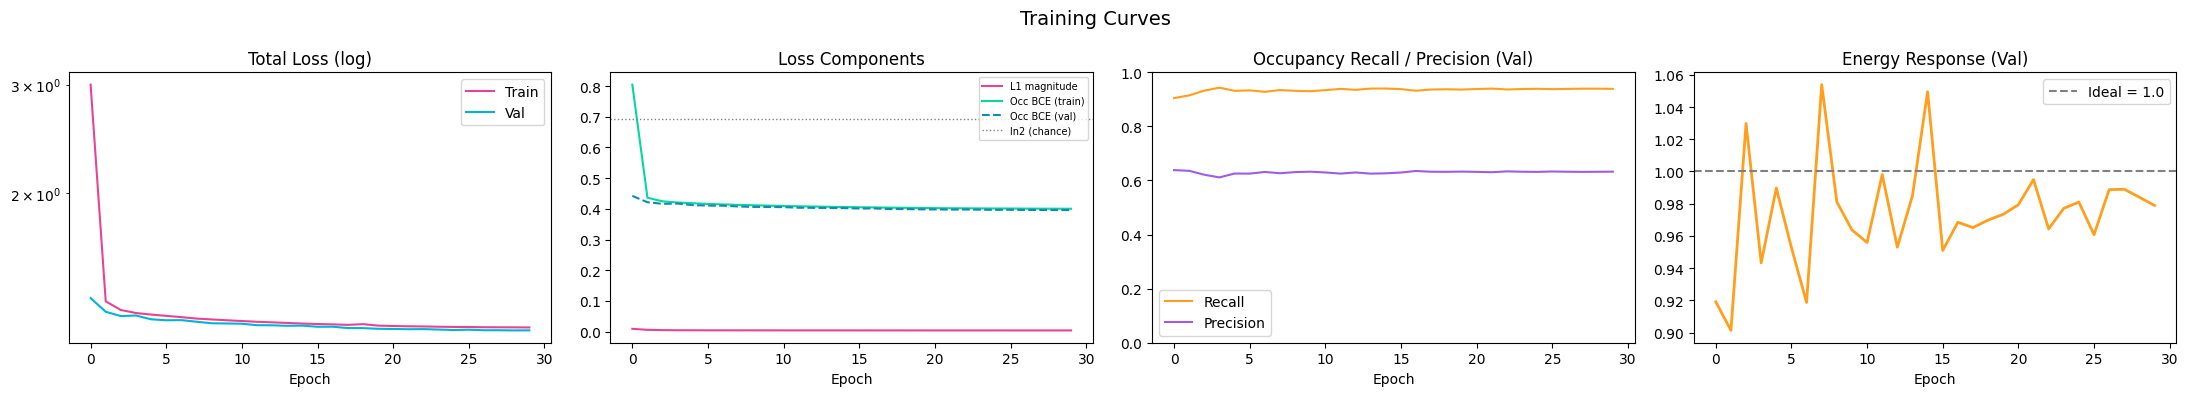

Final | occ_BCE(val)=0.396  recall=0.939  precision=0.633  response=0.979


In [23]:
fig, axes = plt.subplots(1, 4, figsize=(22, 4))
fig.suptitle('Training Curves', fontsize=14)

axes[0].plot(history['train_loss'], label='Train', color='#e84393')
axes[0].plot(history['val_loss'],   label='Val',   color='#00b4d8')
axes[0].set_yscale('log')
axes[0].set_title('Total Loss (log)'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(history['train_l_rec'], label='L1 magnitude',      color='#e84393')
axes[1].plot(history['train_l_occ'], label='Occ BCE (train)',   color='#06d6a0')
axes[1].plot(history['val_l_occ'],   label='Occ BCE (val)',     color='#118ab2', ls='--')
axes[1].axhline(0.6931, color='gray', ls=':', lw=1, label='ln2 (chance)')
axes[1].set_title('Loss Components'); axes[1].set_xlabel('Epoch'); axes[1].legend(fontsize=7)

axes[2].plot(history['val_recall'],    label='Recall',    color='#ff9f1c')
axes[2].plot(history['val_precision'], label='Precision', color='#9b5de5')
axes[2].set_ylim(0, 1)
axes[2].set_title('Occupancy Recall / Precision (Val)')
axes[2].set_xlabel('Epoch'); axes[2].legend()

axes[3].plot(history['val_response'], color='#ff9f1c', lw=2)
axes[3].axhline(1.0, color='gray', ls='--', label='Ideal = 1.0')
axes[3].set_title('Energy Response (Val)'); axes[3].set_xlabel('Epoch'); axes[3].legend()

plt.tight_layout()
savefig(fig, 'training_curves')
plt.show()

print(f"Final | occ_BCE(val)={history['val_l_occ'][-1]:.3f}  "
      f"recall={history['val_recall'][-1]:.3f}  "
      f"precision={history['val_precision'][-1]:.3f}  "
      f"response={history['val_response'][-1]:.3f}")
if history['val_l_occ'][-1] > 0.65:
    print('  !! Occupancy BCE near ln2 (0.693) — gate not learning. '
          'Try raising occ_net LR or lambda_occ.')


In [24]:
# ── Load best checkpoint (robust: loads optimizer+scheduler too if present) ───
def _try_load_checkpoint(path):
    if not os.path.exists(path):
        print(f'No checkpoint at {path} — using in-memory trained model.')
        return False
    ckpt = torch.load(path, map_location=DEVICE)
    try:
        # Use non-strict load if we detect a compiled-model prefix mismatch.
        state = ckpt['model']
        try:
            model.load_state_dict(state, strict=True)
        except RuntimeError:
            # torch.compile wraps keys with '_orig_mod.' prefix; strip it.
            state = {k.replace('_orig_mod.', ''): v for k, v in state.items()}
            model.load_state_dict(state, strict=True)
        # Restore optimizer and scheduler if available.
        if 'optimizer' in ckpt:
            optimizer.load_state_dict(ckpt['optimizer'])
        if 'scheduler' in ckpt:
            scheduler.load_state_dict(ckpt['scheduler'])
        model.eval()
        print(f'Loaded checkpoint  epoch={ckpt.get("epoch","?")}  '
              f'val_loss={ckpt.get("val_loss", float("nan")):.5f}')
        return True
    except Exception as e:
        print(f'Checkpoint mismatch — keeping in-memory model.  ({type(e).__name__}: {e})')
        return False

_try_load_checkpoint(CKPT_PATH)
model.eval()

# ── Unwrap DataParallel for inference ─────────────────────────────────────────
# Always use the raw module for inference, diagnostics, and eval.
# The DataParallel wrapper is only needed during training (large batches).
# Using it for single-sample calls or calls with custom kwargs (return_parts=True)
# causes replica 1 to receive empty/malformed inputs → TypeError.
_model = model.module if isinstance(model, torch.nn.DataParallel) else model

# ── Occupancy diagnostic ──────────────────────────────────────────────────────
with torch.no_grad():
    s  = val_dataset[0]
    pc = s['lr_pc'].unsqueeze(0).to(DEVICE, non_blocking=True)
    rq = torch.rand(1, 2000, 2, device=DEVICE) * 2 - 1

    # FIX: call _model (unwrapped) instead of model (DataParallel wrapper).
    # With batch_size=1, DataParallel tries to scatter across 2 GPUs and
    # replica 1 receives empty input → GatedINR.forward() missing positional args.
    _, occ_logit, mag = _model(pc, rq, return_parts=True)

    occ = torch.sigmoid(occ_logit)
    print(f'Occupancy on 2000 random queries:')
    print(f'  sigmoid(occ): min={occ.min():.3f} mean={occ.mean():.3f} '
          f'max={occ.max():.3f}')
    print(f'  frac > OCC_THRESHOLD ({OCC_THRESHOLD}): '
          f'{(occ > OCC_THRESHOLD).float().mean():.3%}')
    print(f'  magnitude:    mean={mag.mean():.4f} max={mag.max():.4f}')

    # FIX: also use _model for rasterise — same DataParallel scattering issue.
    img_diag = _model.rasterise(pc, *HR_RES).squeeze(0).cpu().numpy()
    print(f'  rasterised {HR_RES}: sum={img_diag.sum():.3f}  '
          f'active(>1e-3)={int((img_diag > 1e-3).sum())}/{img_diag.size}')
    if img_diag.sum() < 1e-3:
        print('  !! OUTPUT BLACK — lower OCC_THRESHOLD or train more epochs.')


def compute_psnr(pred, gt, max_val=1.0):
    mse = np.mean((pred - gt) ** 2)
    return 20 * np.log10(max_val / (np.sqrt(mse) + 1e-10))

def compute_energy_response(pred, gt):
    return pred.sum() / (gt.sum() + 1e-8)

def bicubic_upsample(lr, target_H, target_W):
    t  = torch.from_numpy(lr).unsqueeze(0)
    up = F.interpolate(t, size=(target_H, target_W),
                       mode='bicubic', align_corners=False)
    return up.squeeze(0).numpy().clip(0, None)


# ── Batched evaluation (groups BATCH_SIZE samples) ───────────────────────────
N_EVAL   = min(64, len(val_dataset))
metrics  = {k: [] for k in ['psnr_bicubic', 'psnr_model',
                              'response_bicubic', 'response_model',
                              'l1_bicubic',   'l1_model']}
HR_H, HR_W = HR_RES

with torch.no_grad():
    # FIX: use _model (unwrapped) for rasterise — avoids DataParallel scattering
    # issues on the final batch when len(batch) < num_gpus (e.g. last batch has
    # 1 sample but you have 2 GPUs → replica 1 gets empty tensor → crash).
    for batch_start in tqdm(range(0, N_EVAL, BATCH_SIZE),
                             desc='Evaluating', leave=True):
        batch_end     = min(batch_start + BATCH_SIZE, N_EVAL)
        batch_indices = list(range(batch_start, batch_end))
        samples       = [val_dataset[i] for i in batch_indices]

        lr_pc_batch = torch.stack([s['lr_pc'] for s in samples]).to(DEVICE, non_blocking=True)

        # FIX: _model.rasterise instead of model.rasterise
        sr_batch = _model.rasterise(lr_pc_batch, HR_H, HR_W).cpu().numpy()   # (B, C, H, W)

        for j, sample in enumerate(samples):
            hr_gt  = sample['hr_img'].numpy()
            lr_img = sample['lr_img'].numpy()
            bic    = bicubic_upsample(lr_img, HR_H, HR_W)
            sr     = sr_batch[j]

            metrics['psnr_bicubic'].append(compute_psnr(bic, hr_gt))
            metrics['psnr_model'].append(compute_psnr(sr, hr_gt))
            metrics['response_bicubic'].append(compute_energy_response(bic, hr_gt))
            metrics['response_model'].append(compute_energy_response(sr, hr_gt))
            metrics['l1_bicubic'].append(np.abs(bic - hr_gt).mean())
            metrics['l1_model'].append(np.abs(sr - hr_gt).mean())

print('\n=== Evaluation Results ===')
print(f'{"Metric":25s}  {"Bicubic":>10s}  {"INR-SR (ours)":>14s}')
print('-' * 56)
for m_bic, m_mod, label in [
    (metrics['psnr_bicubic'],     metrics['psnr_model'],     'PSNR (dB) up'),
    (metrics['response_bicubic'], metrics['response_model'], 'Energy Response ->1.0'),
    (metrics['l1_bicubic'],       metrics['l1_model'],       'L1 Error down'),
]:
    print(f'{label:25s}  {np.mean(m_bic):10.4f}  {np.mean(m_mod):14.4f}')

Checkpoint mismatch — keeping in-memory model.  (RuntimeError: Error(s) in loading state_dict for DataParallel:
	Missing key(s) in state_dict: "module.encoder.mlp.0.weight", "module.encoder.mlp.0.bias", "module.encoder.mlp.1.weight", "module.encoder.mlp.1.bias", "module.encoder.mlp.1.running_mean", "module.encoder.mlp.1.running_var", "module.encoder.mlp.3.weight", "module.encoder.mlp.3.bias", "module.encoder.mlp.4.weight", "module.encoder.mlp.4.bias", "module.encoder.mlp.4.running_mean", "module.encoder.mlp.4.running_var", "module.encoder.mlp.6.weight", "module.encoder.mlp.6.bias", "module.encoder.mlp.7.weight", "module.encoder.mlp.7.bias", "module.encoder.mlp.7.running_mean", "module.encoder.mlp.7.running_var", "module.encoder.head.0.weight", "module.encoder.head.0.bias", "module.encoder.head.1.weight", "module.encoder.head.1.bias", "module.encoder.head.3.weight", "module.encoder.head.3.bias", "module.decoder.fourier_mag.freqs", "module.decoder.fourier_occ.freqs", "module.decoder.mag_

Evaluating: 100%|██████████| 1/1 [00:00<00:00,  1.99it/s]


=== Evaluation Results ===
Metric                        Bicubic   INR-SR (ours)
--------------------------------------------------------
PSNR (dB) up                  47.7197         57.7742
Energy Response ->1.0          3.9788          0.7609
L1 Error down                  0.0048          0.0005


Saved: /kaggle/working/figures/2026-06-21/sr_comparison.png


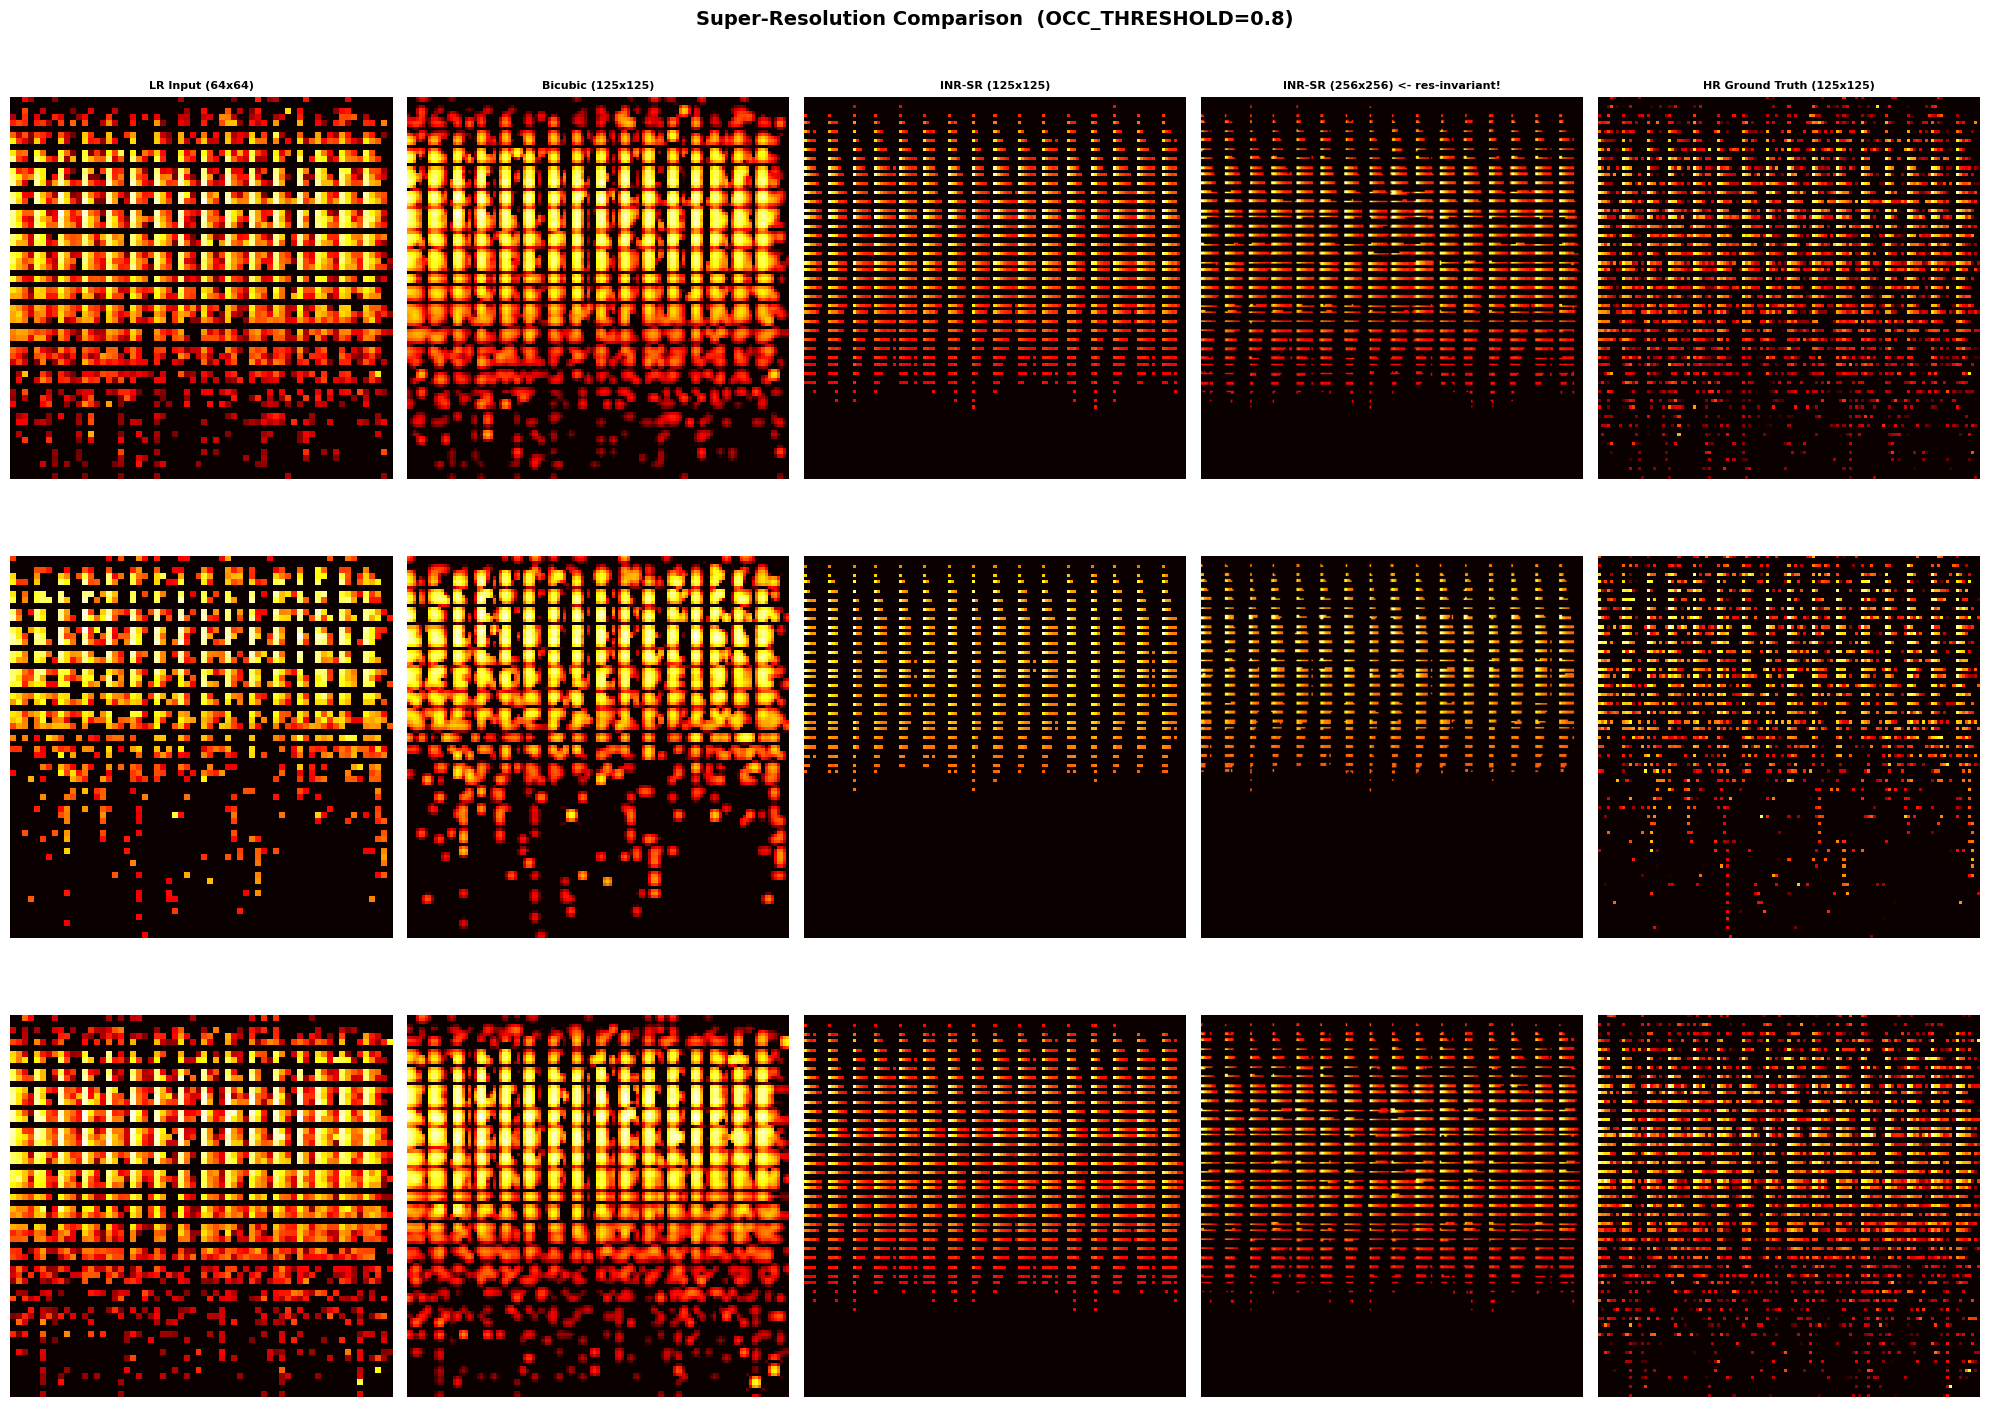

In [19]:
N_VIS = 3
fig   = plt.figure(figsize=(20, 5 * N_VIS))
fig.suptitle(f'Super-Resolution Comparison  (OCC_THRESHOLD={OCC_THRESHOLD})',
             fontsize=14, fontweight='bold')
col_titles = ['LR Input (64x64)', 'Bicubic (125x125)',
              'INR-SR (125x125)', 'INR-SR (256x256) <- res-invariant!',
              'HR Ground Truth (125x125)']

with torch.no_grad():
    for row in range(N_VIS):
        sample  = val_dataset[row]
        lr_pc   = sample['lr_pc'].unsqueeze(0).to(DEVICE, non_blocking=True)
        hr_gt   = sample['hr_img'].numpy()
        lr_img  = sample['lr_img'].numpy()
        bic_sr  = bicubic_upsample(lr_img, *HR_RES)

        # FIX: use _model (unwrapped from DataParallel) — DataParallel does not
        # forward arbitrary method calls like .rasterise(); only .forward() is
        # dispatched through it. Calling model.rasterise() → AttributeError.
        inr_sr  = _model.rasterise(lr_pc, *HR_RES).squeeze(0).cpu().numpy()
        inr_sr2 = _model.rasterise(lr_pc, 256, 256).squeeze(0).cpu().numpy()

        images_row = [lr_img, bic_sr, inr_sr, inr_sr2, hr_gt]
        for col, (arr, title) in enumerate(zip(images_row, col_titles)):
            ax   = fig.add_subplot(N_VIS, 5, row * 5 + col + 1)
            a    = arr[0]
            vmax = max(float(a.max()), 1e-3)
            vmin = max(vmax * 1e-3, 1e-6)
            ax.imshow(np.clip(a, vmin, None), cmap='hot',
                      norm=LogNorm(vmin=vmin, vmax=vmax), aspect='equal')
            if row == 0:
                ax.set_title(title, fontsize=8, fontweight='bold')
            ax.set_xlabel(f'E={arr.sum():.3f}  active={int((a>1e-3).sum())}',
                          fontsize=7)
            ax.axis('off')

plt.tight_layout()
savefig(fig, 'sr_comparison')
plt.show()

Saved: /kaggle/working/figures/2026-06-21/resolution_invariance.png


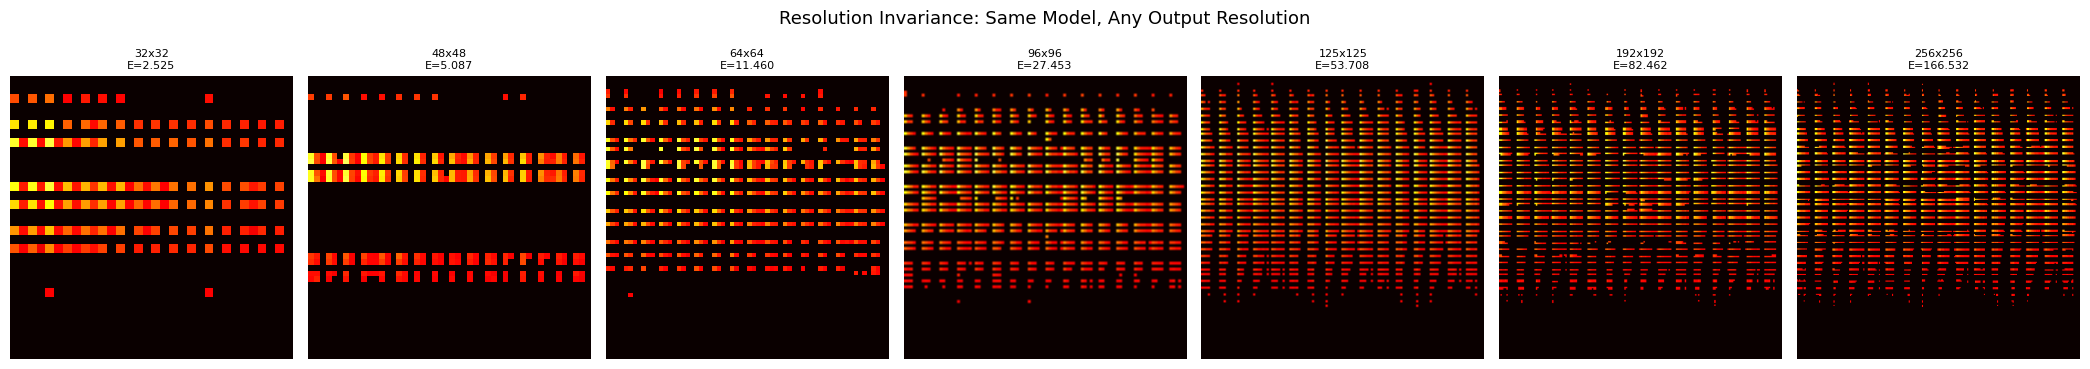

In [25]:
sample  = val_dataset[0]
lr_pc   = sample['lr_pc'].unsqueeze(0).to(DEVICE, non_blocking=True)
resolutions = [32, 48, 64, 96, 125, 192, 256]
fig, axes = plt.subplots(1, len(resolutions), figsize=(21, 4))
fig.suptitle('Resolution Invariance: Same Model, Any Output Resolution', fontsize=13)

with torch.no_grad():
    for ax, r in zip(axes, resolutions):
        # FIX: _model instead of model — DataParallel doesn't expose .rasterise()
        sr      = _model.rasterise(lr_pc, r, r).squeeze(0).cpu().numpy()
        display = np.clip(sr[0], 1e-6, None)
        ax.imshow(display, cmap='hot',
                  norm=LogNorm(vmin=1e-4, vmax=1.0), aspect='equal')
        ax.set_title(f'{r}x{r}\nE={sr.sum():.3f}', fontsize=8)
        ax.axis('off')

plt.tight_layout()
savefig(fig, 'resolution_invariance')
plt.show()

Saved: /kaggle/working/figures/2026-06-21/physics_validation.png


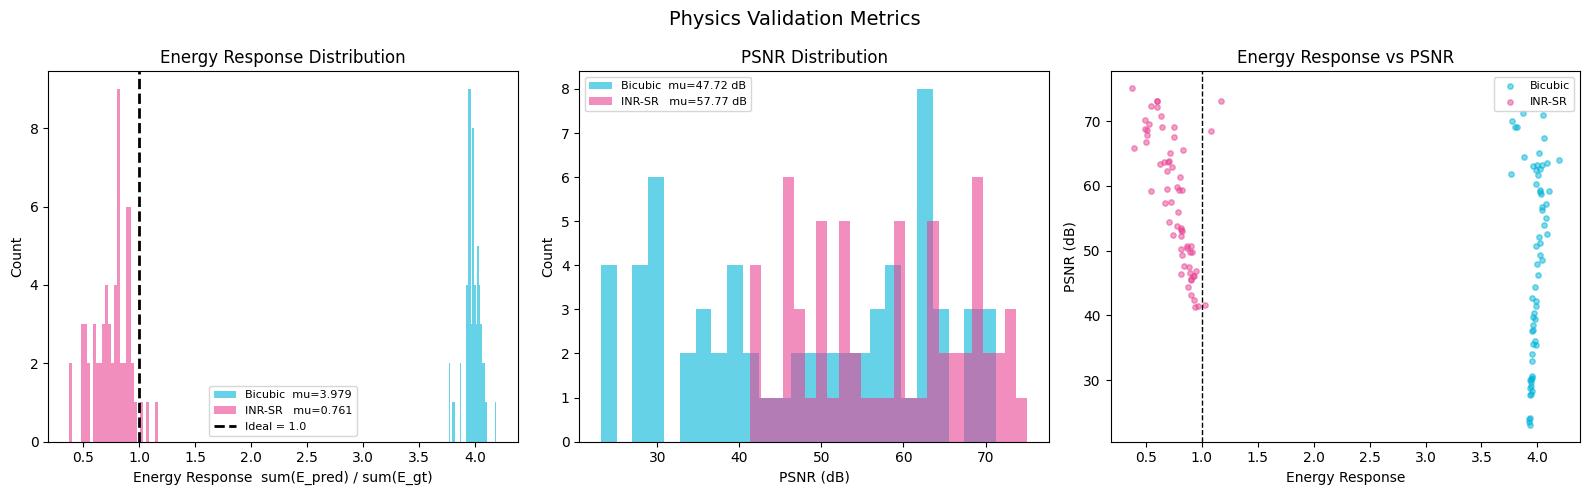

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Physics Validation Metrics', fontsize=14)

axes[0].hist(metrics['response_bicubic'], bins=30, alpha=0.6, color='#00b4d8',
             label=f'Bicubic  mu={np.mean(metrics["response_bicubic"]):.3f}')
axes[0].hist(metrics['response_model'],   bins=30, alpha=0.6, color='#e84393',
             label=f'INR-SR   mu={np.mean(metrics["response_model"]):.3f}')
axes[0].axvline(1.0, color='k', ls='--', lw=2, label='Ideal = 1.0')
axes[0].set_xlabel('Energy Response  sum(E_pred) / sum(E_gt)')
axes[0].set_ylabel('Count')
axes[0].set_title('Energy Response Distribution')
axes[0].legend(fontsize=8)

axes[1].hist(metrics['psnr_bicubic'], bins=25, alpha=0.6, color='#00b4d8',
             label=f'Bicubic  mu={np.mean(metrics["psnr_bicubic"]):.2f} dB')
axes[1].hist(metrics['psnr_model'],   bins=25, alpha=0.6, color='#e84393',
             label=f'INR-SR   mu={np.mean(metrics["psnr_model"]):.2f} dB')
axes[1].set_xlabel('PSNR (dB)'); axes[1].set_ylabel('Count')
axes[1].set_title('PSNR Distribution'); axes[1].legend(fontsize=8)

axes[2].scatter(metrics['response_bicubic'], metrics['psnr_bicubic'],
                alpha=0.5, s=15, color='#00b4d8', label='Bicubic')
axes[2].scatter(metrics['response_model'],   metrics['psnr_model'],
                alpha=0.5, s=15, color='#e84393', label='INR-SR')
axes[2].axvline(1.0, color='k', ls='--', lw=1)
axes[2].set_xlabel('Energy Response'); axes[2].set_ylabel('PSNR (dB)')
axes[2].set_title('Energy Response vs PSNR')
axes[2].legend(fontsize=8)

plt.tight_layout()
savefig(fig, 'physics_validation')
plt.show()


Predicting 1,000,000 points...


Total points     : 1,000,000
Active after ZS  : 320,902  (32.09%)
Saved: /kaggle/working/figures/2026-06-21/1M_point_prediction.png


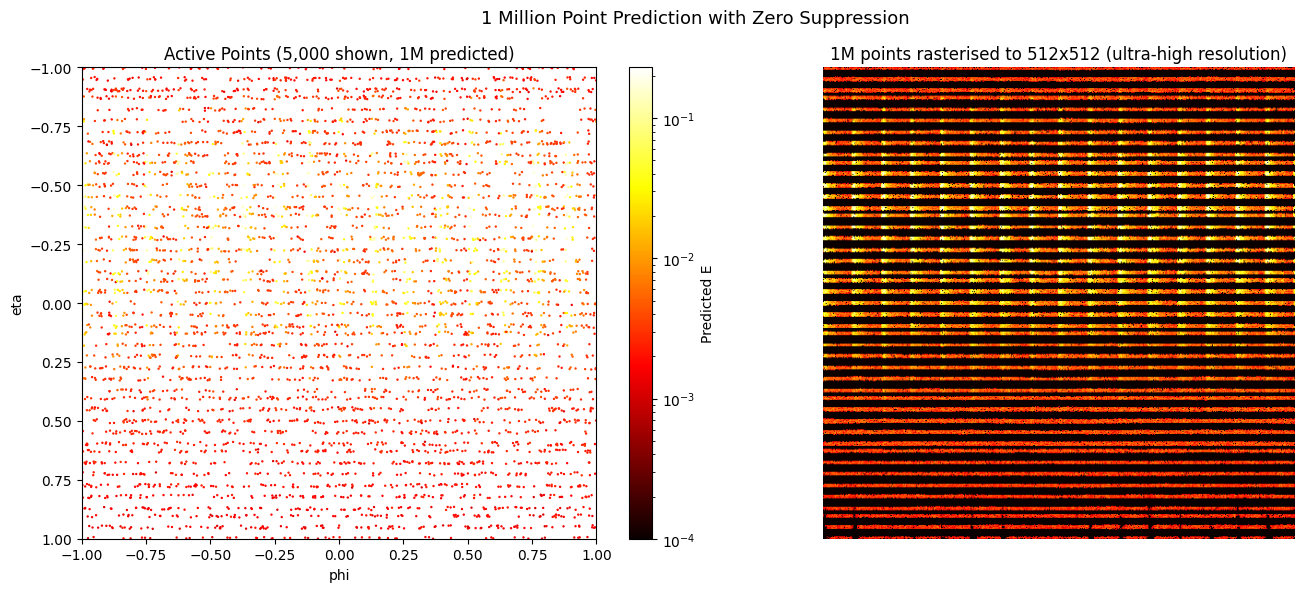

137598

In [30]:
@torch.no_grad()
def predict_million_points(lr_pc: torch.Tensor,
                            n_points: int = 1_000_000,
                            chunk_size: int = 50_000) -> tuple:
    model.eval()
    dev          = lr_pc.device
    all_coords   = torch.rand(n_points, 2, device=dev) * 2 - 1

    # ✅ Unwrap DataParallel to access .encoder / .decoder directly
    m = model.module if isinstance(model, torch.nn.DataParallel) else model

    all_energies = []
    z = m.encoder(lr_pc)   # encode once — (1, latent_dim)

    for start in tqdm(range(0, n_points, chunk_size),
                      desc='Decoding chunks', leave=False):
        end    = min(start + chunk_size, n_points)
        coords = all_coords[start:end].unsqueeze(0)   # (1, chunk, 2)
        E_pred = m.decoder(z, coords)                 # (1, chunk, C)
        all_energies.append(E_pred.squeeze(0).cpu())

    all_energies = torch.cat(all_energies, dim=0)
    return all_coords.cpu().numpy(), all_energies.numpy()


sample    = val_dataset[0]
lr_pc_t   = sample['lr_pc'].unsqueeze(0).to(DEVICE, non_blocking=True)

print('Predicting 1,000,000 points...')
coords_1m, energies_1m = predict_million_points(lr_pc_t, n_points=1_000_000)

active_mask     = energies_1m[:, 0] > ZERO_SUPPRESSION_THRESHOLD
active_coords   = coords_1m[active_mask]
active_energies = energies_1m[active_mask, 0]

print(f'Total points     : {len(coords_1m):,}')
print(f'Active after ZS  : {active_mask.sum():,}  ({active_mask.mean():.2%})')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('1 Million Point Prediction with Zero Suppression', fontsize=13)

n_show = min(5000, len(active_coords))
vmax   = float(active_energies.max()) if len(active_energies) > 0 else 1.0
sc = axes[0].scatter(active_coords[:n_show, 1], active_coords[:n_show, 0],
                     c=active_energies[:n_show], cmap='hot', s=0.5,
                     norm=LogNorm(vmin=1e-4, vmax=vmax))
axes[0].set_xlim(-1, 1); axes[0].set_ylim(-1, 1); axes[0].invert_yaxis()
axes[0].set_title(f'Active Points ({n_show:,} shown, 1M predicted)')
axes[0].set_xlabel('phi'); axes[0].set_ylabel('eta')
plt.colorbar(sc, ax=axes[0], label='Predicted E')

# Rasterise all 1M active points to 512x512.
if len(active_coords) > 0:
    hr_pc_arr = np.concatenate([active_coords, active_energies[:, None]], axis=-1)
    img_512   = pointcloud_to_image(hr_pc_arr, 512, 512, C=1, aggregation='sum')
    axes[1].imshow(np.clip(img_512[0], 1e-6, None), cmap='hot',
                   norm=LogNorm(vmin=1e-4, vmax=1.0), aspect='equal')
    axes[1].set_title('1M points rasterised to 512x512 (ultra-high resolution)')
else:
    axes[1].set_title('No active points (model may need more training)')
axes[1].axis('off')

plt.tight_layout()
savefig(fig, '1M_point_prediction')
plt.show()

if DEVICE == 'cuda':
    torch.cuda.empty_cache()
gc.collect()


In [28]:
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print('=' * 64)
print('  CMS CALORIMETER SR — RESULTS SUMMARY')
print('  GSoC 2026 | ML4Sci | Rajveer Rathod')
print('=' * 64)
print(f'\n  Dataset:  {N:,} jets  C={C}  orig {CELL_SHAPE[1]}x{CELL_SHAPE[2]}')
print(f'  LR res:   {LR_RES}  ->  HR target: {HR_RES}')
print(f'  Model:    PointNet encoder + gated SIREN-INR decoder')
print(f'            (occupancy classification x magnitude regression)')
print(f'  Params:   {trainable:,}')
print(f'  AMP:      {USE_AMP}  |  workers: {NUM_WORKERS}  |  compile: '
      f'{"yes (CUDA)" if DEVICE == "cuda" else "no"}')

print(f'\n  {"Metric":30s}  {"Bicubic":>10s}  {"INR-SR":>10s}  Delta')
print('  ' + '-' * 60)

b_psnr = np.mean(metrics['psnr_bicubic'])
m_psnr = np.mean(metrics['psnr_model'])
b_resp = np.mean(metrics['response_bicubic'])
m_resp = np.mean(metrics['response_model'])
b_l1   = np.mean(metrics['l1_bicubic'])
m_l1   = np.mean(metrics['l1_model'])

def delta(a, b, higher_is_better=True):
    d = b - a
    arrow = 'up' if (d > 0) == higher_is_better else 'dn'
    return f'{arrow} {abs(d):.4f}'

print(f'  {"PSNR (dB) up":30s}  {b_psnr:10.3f}  {m_psnr:10.3f}  '
      f'{delta(b_psnr, m_psnr, True)}')
print(f'  {"Energy Response (->1.0)":30s}  {b_resp:10.4f}  {m_resp:10.4f}  '
      f'{delta(abs(b_resp-1), abs(m_resp-1), False)}')
print(f'  {"L1 Error down":30s}  {b_l1:10.5f}  {m_l1:10.5f}  '
      f'{delta(b_l1, m_l1, False)}')

print(f'\n  Occupancy gate:')
print(f'    BCE (val)   {history["val_l_occ"][-1]:.4f}  (chance=0.693)')
print(f'    Recall      {history["val_recall"][-1]:.4f}')
print(f'    Precision   {history["val_precision"][-1]:.4f}')

print(f'\n  Resolution invariant : yes (tested 32 to 512 px)')
try:
    print(f'  1M point prediction  : yes ({active_mask.mean():.1%} active after ZS)')
except NameError:
    print('  1M point prediction  : run cell 22 first')
print(f'  Checkpoint saved     : {CKPT_PATH}')
print('=' * 64)


  CMS CALORIMETER SR — RESULTS SUMMARY
  GSoC 2026 | ML4Sci | Rajveer Rathod

  Dataset:  200,000 jets  C=1  orig 45x144
  LR res:   (64, 64)  ->  HR target: (125, 125)
  Model:    PointNet encoder + gated SIREN-INR decoder
            (occupancy classification x magnitude regression)
  Params:   550,018
  AMP:      True  |  workers: 4  |  compile: yes (CUDA)

  Metric                             Bicubic      INR-SR  Delta
  ------------------------------------------------------------
  PSNR (dB) up                        47.720      57.774  up 10.0545
  Energy Response (->1.0)             3.9788      0.7609  up 2.7397
  L1 Error down                      0.00479     0.00050  up 0.0043

  Occupancy gate:
    BCE (val)   0.3961  (chance=0.693)
    Recall      0.9389
    Precision   0.6327

  Resolution invariant : yes (tested 32 to 512 px)
  1M point prediction  : run cell 22 first
  Checkpoint saved     : /kaggle/working/checkpoints/best_sr_model.pt


In [29]:
# ── Optional: push checkpoint to HuggingFace Hub ─────────────────────────────
# Uncomment and set your HF token to push.

# from huggingface_hub import HfApi
# api = HfApi(token='YOUR_HF_TOKEN')
# api.upload_file(
#     path_or_fileobj=CKPT_PATH,
#     path_in_repo='checkpoints/best_sr_model.pt',
#     repo_id='YOUR_HF_USERNAME/cms-calorimeter-superres-inr',
#     repo_type='model',
# )
# print('Pushed to HuggingFace Hub.')

print(f'Notebook complete.')
print(f'Checkpoint : {CKPT_PATH}')
print(f'Figures    : {FIGURES_DIR}')
print(f'Cache      : {CACHE_DIR}')


Notebook complete.
Checkpoint : /kaggle/working/checkpoints/best_sr_model.pt
Figures    : /kaggle/working/figures/2026-06-21
Cache      : /kaggle/working/cache
